<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Hybrid_SQL_Qubit_QuTiP_CuPy_Study_Surface_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
# @title Cell 1: Install, configure, and define the hybrid CuPy and QuTiP model

# =============================================================================
# Control knobs
# =============================================================================
INSTALL_DEPENDENCIES = True

SQL_CONVENTION = "noise_ratio"
SCENARIO_DB = {
    "Far below SQL": -10.0,
    "Near below SQL": -3.0102999566,
    "At SQL": 0.0,
    "Near above SQL": 3.0102999566,
    "Far above SQL": 10.0,
}

OMEGA_RABI_MHZ = 5.0
DETUNING_MHZ = 0.0
RAMSEY_DETUNING_MHZ = 1.0

T1_SQL_US = 120.0
T2_SQL_US = 80.0

T1_SQL_COUPLED_FRACTION = 0.70
TPHI_SQL_COUPLED_FRACTION = 0.90
T1_RATE_EXPONENT = 1.00
TPHI_RATE_EXPONENT = 1.00

TIME_MAX_US = 6.0
N_TIME = 2401
ETA_MIN = 0.05
ETA_MAX = 20.0
N_ETA = 181

QUTIP_NSTEPS = 20000
QUTIP_ATOL = 1.0e-11
QUTIP_RTOL = 1.0e-9

# The 2D heatmap retains the complete time range. The 3D surface uses a
# focused cycle window so the oscillatory sheet remains legible.
SURFACE_MAX_RABI_CYCLES = 10.0
SURFACE_TIME_POINTS = 301
SURFACE_ETA_POINTS = 91
SURFACE_ELEVATION_DEG = 30.0
SURFACE_AZIMUTH_DEG = -132.0
SURFACE_CONTOUR_LEVELS = 5

FFT_MAX_MHZ = 15.0
SENSITIVITY_ALPHA_MIN = 0.25
SENSITIVITY_ALPHA_MAX = 2.00
N_SENSITIVITY_ALPHA = 121

RANDOM_SEED = 17

# =============================================================================
# Environment setup
# =============================================================================
import subprocess
import sys

if INSTALL_DEPENDENCIES:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "uv"],
        check=True,
    )
    subprocess.run(
        ["apt-get", "-qq", "update"],
        check=True,
    )
    subprocess.run(
        ["apt-get", "-qq", "install", "-y", "graphviz"],
        check=True,
    )
    subprocess.run(
        [
            "uv",
            "pip",
            "install",
            "--system",
            "-q",
            "qutip==5.3.0",
            "cupy-cuda12x",
            "graphviz",
            "pandas",
        ],
        check=True,
    )

# =============================================================================
# Imports
# =============================================================================
import io
import math
import time
from typing import Any, Dict, Iterable, Tuple

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qutip as qt
from graphviz import Source
from IPython.display import Image, display
from matplotlib import rcParams
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator

rcParams["figure.dpi"] = 250
rcParams["savefig.dpi"] = 250
rcParams["font.size"] = 10
rcParams["axes.grid"] = False

np.random.seed(RANDOM_SEED)

# =============================================================================
# Hardware and model validation
# =============================================================================
if SQL_CONVENTION in {"noise_ratio", "gain_ratio"}:
    pass
else:
    raise ValueError(
        "SQL_CONVENTION must equal 'noise_ratio' or 'gain_ratio'."
    )

device_count = cp.cuda.runtime.getDeviceCount()
if device_count < 1:
    raise RuntimeError("A CUDA device is required for the CuPy sweep.")

device_properties = cp.cuda.runtime.getDeviceProperties(0)
gpu_name = device_properties["name"]
if isinstance(gpu_name, bytes):
    gpu_name = gpu_name.decode("utf-8")

gamma_1_sql = 1.0 / T1_SQL_US
gamma_phi_sql = (1.0 / T2_SQL_US) - (0.5 / T1_SQL_US)

if gamma_phi_sql <= 0.0:
    raise ValueError(
        "T2_SQL_US must be smaller than two times T1_SQL_US."
    )

tphi_sql_us = 1.0 / gamma_phi_sql

print(f"GPU: {gpu_name}")
print(f"CuPy: {cp.__version__}")
print(f"QuTiP: {qt.__version__}")
print(f"SQL reference Tphi: {tphi_sql_us:.6f} us")

# =============================================================================
# SQL convention and rate model
# =============================================================================
def db_to_noise_ratio(db_value: Any) -> Any:
    """Map signed SQL decibels to the effective noise ratio eta."""
    linear_ratio = 10.0 ** (np.asarray(db_value, dtype=float) / 10.0)
    if SQL_CONVENTION == "noise_ratio":
        return linear_ratio
    return 1.0 / linear_ratio


def noise_ratio_to_db(eta_value: Any) -> Any:
    """Map the effective noise ratio eta to the selected SQL decibels."""
    eta_array = np.asarray(eta_value, dtype=float)
    db_value = 10.0 * np.log10(eta_array)
    if SQL_CONVENTION == "noise_ratio":
        return db_value
    return -db_value


def sql_rate_model(
    eta: Any,
    xp: Any,
    tphi_exponent: float = TPHI_RATE_EXPONENT,
) -> Tuple[Any, Any, Any, Any, Any]:
    """Return relaxation, dephasing, and coherence quantities.

    The model assigns a finite noise floor to each rate. At eta equal to one,
    the rates reproduce the selected SQL reference T1 and T2 values.
    """
    eta_array = xp.asarray(eta, dtype=xp.float64)

    gamma_1_factor = (
        1.0
        - T1_SQL_COUPLED_FRACTION
        + T1_SQL_COUPLED_FRACTION
        * xp.power(eta_array, T1_RATE_EXPONENT)
    )
    gamma_phi_factor = (
        1.0
        - TPHI_SQL_COUPLED_FRACTION
        + TPHI_SQL_COUPLED_FRACTION
        * xp.power(eta_array, tphi_exponent)
    )

    gamma_1 = gamma_1_sql * gamma_1_factor
    gamma_phi = gamma_phi_sql * gamma_phi_factor
    t1_us = 1.0 / gamma_1
    tphi_us = 1.0 / gamma_phi
    t2_us = 1.0 / (0.5 * gamma_1 + gamma_phi)

    return gamma_1, gamma_phi, t1_us, tphi_us, t2_us


# =============================================================================
# Batched CuPy optical Bloch solver
# =============================================================================
def bloch_rhs(
    x_value: cp.ndarray,
    y_value: cp.ndarray,
    z_value: cp.ndarray,
    omega_rad_per_us: float,
    delta_rad_per_us: float,
    gamma_1: cp.ndarray,
    gamma_2: cp.ndarray,
) -> Tuple[cp.ndarray, cp.ndarray, cp.ndarray]:
    """Evaluate the driven, dissipative optical Bloch equations."""
    dx_value = -delta_rad_per_us * y_value - gamma_2 * x_value
    dy_value = (
        delta_rad_per_us * x_value
        - omega_rad_per_us * z_value
        - gamma_2 * y_value
    )
    dz_value = (
        omega_rad_per_us * y_value
        - gamma_1 * (z_value - 1.0)
    )
    return dx_value, dy_value, dz_value


def rk4_bloch_step(
    x_value: cp.ndarray,
    y_value: cp.ndarray,
    z_value: cp.ndarray,
    dt_us: float,
    omega_rad_per_us: float,
    delta_rad_per_us: float,
    gamma_1: cp.ndarray,
    gamma_2: cp.ndarray,
) -> Tuple[cp.ndarray, cp.ndarray, cp.ndarray]:
    """Advance the Bloch vector by one fourth order Runge Kutta step."""
    k1x, k1y, k1z = bloch_rhs(
        x_value,
        y_value,
        z_value,
        omega_rad_per_us,
        delta_rad_per_us,
        gamma_1,
        gamma_2,
    )
    k2x, k2y, k2z = bloch_rhs(
        x_value + 0.5 * dt_us * k1x,
        y_value + 0.5 * dt_us * k1y,
        z_value + 0.5 * dt_us * k1z,
        omega_rad_per_us,
        delta_rad_per_us,
        gamma_1,
        gamma_2,
    )
    k3x, k3y, k3z = bloch_rhs(
        x_value + 0.5 * dt_us * k2x,
        y_value + 0.5 * dt_us * k2y,
        z_value + 0.5 * dt_us * k2z,
        omega_rad_per_us,
        delta_rad_per_us,
        gamma_1,
        gamma_2,
    )
    k4x, k4y, k4z = bloch_rhs(
        x_value + dt_us * k3x,
        y_value + dt_us * k3y,
        z_value + dt_us * k3z,
        omega_rad_per_us,
        delta_rad_per_us,
        gamma_1,
        gamma_2,
    )

    x_next = x_value + (dt_us / 6.0) * (
        k1x + 2.0 * k2x + 2.0 * k3x + k4x
    )
    y_next = y_value + (dt_us / 6.0) * (
        k1y + 2.0 * k2y + 2.0 * k3y + k4y
    )
    z_next = z_value + (dt_us / 6.0) * (
        k1z + 2.0 * k2z + 2.0 * k3z + k4z
    )

    return x_next, y_next, z_next


def simulate_bloch_cupy(
    eta_values: Iterable[float],
    time_us: np.ndarray,
    detuning_mhz: float = DETUNING_MHZ,
) -> Dict[str, np.ndarray]:
    """Simulate many SQL ratios concurrently on the CUDA device."""
    eta_gpu = cp.asarray(list(eta_values), dtype=cp.float64)
    time_array = np.asarray(time_us, dtype=float)

    if time_array.size < 2:
        raise ValueError("The time grid requires at least two samples.")

    dt_us = float(time_array[1] - time_array[0])
    omega_rad_per_us = 2.0 * math.pi * OMEGA_RABI_MHZ
    delta_rad_per_us = 2.0 * math.pi * detuning_mhz

    gamma_1, gamma_phi, t1_us, tphi_us, t2_us = sql_rate_model(
        eta_gpu,
        cp,
    )
    gamma_2 = 0.5 * gamma_1 + gamma_phi

    n_eta = int(eta_gpu.size)
    n_time = int(time_array.size)

    x_value = cp.zeros(n_eta, dtype=cp.float64)
    y_value = cp.zeros(n_eta, dtype=cp.float64)
    z_value = cp.ones(n_eta, dtype=cp.float64)

    x_history = cp.empty((n_eta, n_time), dtype=cp.float64)
    y_history = cp.empty((n_eta, n_time), dtype=cp.float64)
    z_history = cp.empty((n_eta, n_time), dtype=cp.float64)

    start_time = time.perf_counter()

    for index in range(n_time):
        x_history[:, index] = x_value
        y_history[:, index] = y_value
        z_history[:, index] = z_value

        if index + 1 < n_time:
            x_value, y_value, z_value = rk4_bloch_step(
                x_value,
                y_value,
                z_value,
                dt_us,
                omega_rad_per_us,
                delta_rad_per_us,
                gamma_1,
                gamma_2,
            )

    cp.cuda.Stream.null.synchronize()
    elapsed_seconds = time.perf_counter() - start_time

    p_excited = 0.5 * (1.0 - z_history)
    bloch_radius = cp.sqrt(
        x_history**2 + y_history**2 + z_history**2
    )
    purity = 0.5 * (1.0 + bloch_radius**2)

    return {
        "eta": cp.asnumpy(eta_gpu),
        "time_us": time_array,
        "x": cp.asnumpy(x_history),
        "y": cp.asnumpy(y_history),
        "z": cp.asnumpy(z_history),
        "p_excited": cp.asnumpy(p_excited),
        "bloch_radius": cp.asnumpy(bloch_radius),
        "purity": cp.asnumpy(purity),
        "gamma_1_per_us": cp.asnumpy(gamma_1),
        "gamma_phi_per_us": cp.asnumpy(gamma_phi),
        "t1_us": cp.asnumpy(t1_us),
        "tphi_us": cp.asnumpy(tphi_us),
        "t2_us": cp.asnumpy(t2_us),
        "elapsed_seconds": np.asarray(elapsed_seconds),
    }


# =============================================================================
# QuTiP Lindblad reference solver
# =============================================================================
def simulate_qutip_reference(
    eta_values: Iterable[float],
    time_us: np.ndarray,
    detuning_mhz: float = DETUNING_MHZ,
) -> Dict[str, np.ndarray]:
    """Solve the same open qubit model with QuTiP mesolve."""
    eta_array = np.asarray(list(eta_values), dtype=float)
    time_array = np.asarray(time_us, dtype=float)

    ground = qt.basis(2, 0)
    excited = qt.basis(2, 1)
    sigma_x = qt.sigmax()
    sigma_y = qt.sigmay()
    sigma_z = qt.sigmaz()
    sigma_minus = ground * excited.dag()
    excited_projector = excited.proj()

    omega_rad_per_us = 2.0 * math.pi * OMEGA_RABI_MHZ
    delta_rad_per_us = 2.0 * math.pi * detuning_mhz
    hamiltonian = (
        0.5 * delta_rad_per_us * sigma_z
        + 0.5 * omega_rad_per_us * sigma_x
    )

    n_eta = eta_array.size
    n_time = time_array.size

    p_excited = np.empty((n_eta, n_time), dtype=float)
    x_history = np.empty((n_eta, n_time), dtype=float)
    y_history = np.empty((n_eta, n_time), dtype=float)
    z_history = np.empty((n_eta, n_time), dtype=float)
    purity = np.empty((n_eta, n_time), dtype=float)
    entropy_bits = np.empty((n_eta, n_time), dtype=float)
    trace_error = np.empty(n_eta, dtype=float)
    minimum_eigenvalue = np.empty(n_eta, dtype=float)

    start_time = time.perf_counter()

    for index, eta_value in enumerate(eta_array):
        gamma_1, gamma_phi, _, _, _ = sql_rate_model(
            np.asarray([eta_value]),
            np,
        )
        gamma_1_value = float(gamma_1[0])
        gamma_phi_value = float(gamma_phi[0])

        collapse_operators = [
            math.sqrt(gamma_1_value) * sigma_minus,
            math.sqrt(gamma_phi_value / 2.0) * sigma_z,
        ]

        result = qt.mesolve(
            hamiltonian,
            ground.proj(),
            time_array,
            c_ops=collapse_operators,
            e_ops=[
                excited_projector,
                sigma_x,
                sigma_y,
                sigma_z,
            ],
            options={
                "store_states": True,
                "nsteps": QUTIP_NSTEPS,
                "atol": QUTIP_ATOL,
                "rtol": QUTIP_RTOL,
                "max_step": float(time_array[1] - time_array[0]),
                "progress_bar": "",
            },
        )

        p_excited[index] = np.real(result.expect[0])
        x_history[index] = np.real(result.expect[1])
        y_history[index] = np.real(result.expect[2])
        z_history[index] = np.real(result.expect[3])

        purity[index] = np.asarray(
            [float(np.real(state.purity())) for state in result.states]
        )
        entropy_bits[index] = np.asarray(
            [float(qt.entropy_vn(state, base=2)) for state in result.states]
        )

        traces = np.asarray(
            [complex(state.tr()) for state in result.states]
        )
        trace_error[index] = float(
            np.max(np.abs(traces - 1.0))
        )

        eigenvalue_minima = [
            float(np.min(np.real(state.eigenenergies())))
            for state in result.states
        ]
        minimum_eigenvalue[index] = float(np.min(eigenvalue_minima))

    elapsed_seconds = time.perf_counter() - start_time

    return {
        "eta": eta_array,
        "time_us": time_array,
        "x": x_history,
        "y": y_history,
        "z": z_history,
        "p_excited": p_excited,
        "purity": purity,
        "entropy_bits": entropy_bits,
        "trace_error": trace_error,
        "minimum_eigenvalue": minimum_eigenvalue,
        "elapsed_seconds": np.asarray(elapsed_seconds),
    }


# =============================================================================
# In memory Graphviz renderer
# =============================================================================
def display_graphviz(dot_source: str) -> None:
    """Render a Graphviz diagram as an in memory PNG."""
    png_bytes = Source(dot_source).pipe(format="png")
    display(Image(data=png_bytes))


print(
    "\nModel convention: eta = effective noise / SQL noise. "
    "Values below one improve the assumed noise budget."
)
print(
    "The rate model includes finite floors, so eta approaching zero "
    "produces finite T1 and Tphi values."
)

GPU: NVIDIA L4
CuPy: 14.0.1
QuTiP: 5.3.0
SQL reference Tphi: 120.000000 us

Model convention: eta = effective noise / SQL noise. Values below one improve the assumed noise budget.
The rate model includes finite floors, so eta approaching zero produces finite T1 and Tphi values.


Running the five scenario CuPy simulation.
Running the dense CuPy SQL sweep.
Running the QuTiP Lindblad reference simulations.
CuPy scenario time: 3.864625 s
CuPy dense sweep time: 3.165927 s
QuTiP reference time: 2.080776 s


,Scenario,SQL level (dB),Noise ratio eta,T1 (us),Tphi (us),T2 (us),T2 / (2 T1),Pi pulse fidelity,Rabi cycles in T2,Linewidth (MHz),Minimum purity,Maximum entropy (bits),Max |QuTiP minus CuPy|,Max Bloch error,Max trace error,Minimum rho eigenvalue
0,Far below SQL,-10.00000000,0.1,324.32432432,631.57894737,320.00000000,0.49333333,0.99984481,1600.00000000,0.00099472,0.98171742,0.07562002,0.00002909,0.00005864,2.22044605e-16,0.0
1,Near below SQL,-3.01029996,0.5,184.61538461,218.18181818,137.14285714,0.37142857,0.99968235,685.71428571,0.00232101,0.96329142,0.13410148,0.00002852,0.00005748,2.22044605e-16,0.0
2,At SQL,0.00000000,1.0,120.00000000,120.00000000,80.00000000,0.33333333,0.99947933,400.00000000,0.00397887,0.94124592,0.19586819,0.00002784,0.00005609,2.22044605e-16,0.0
3,Near above SQL,3.01029996,2.0,70.58823529,63.15789474,43.63636364,0.30909091,0.99907345,218.18181818,0.00729460,0.90024853,0.29753861,0.00002653,0.00005344,2.22044605e-16,0.0
4,Far above SQL,10.00000000,10.0,16.43835616,13.18681319,9.41176471,0.28627451,0.99583379,47.05882353,0.03382043,0.68327872,0.71645476,0.00001801,0.00003618,2.22044605e-16,0.0


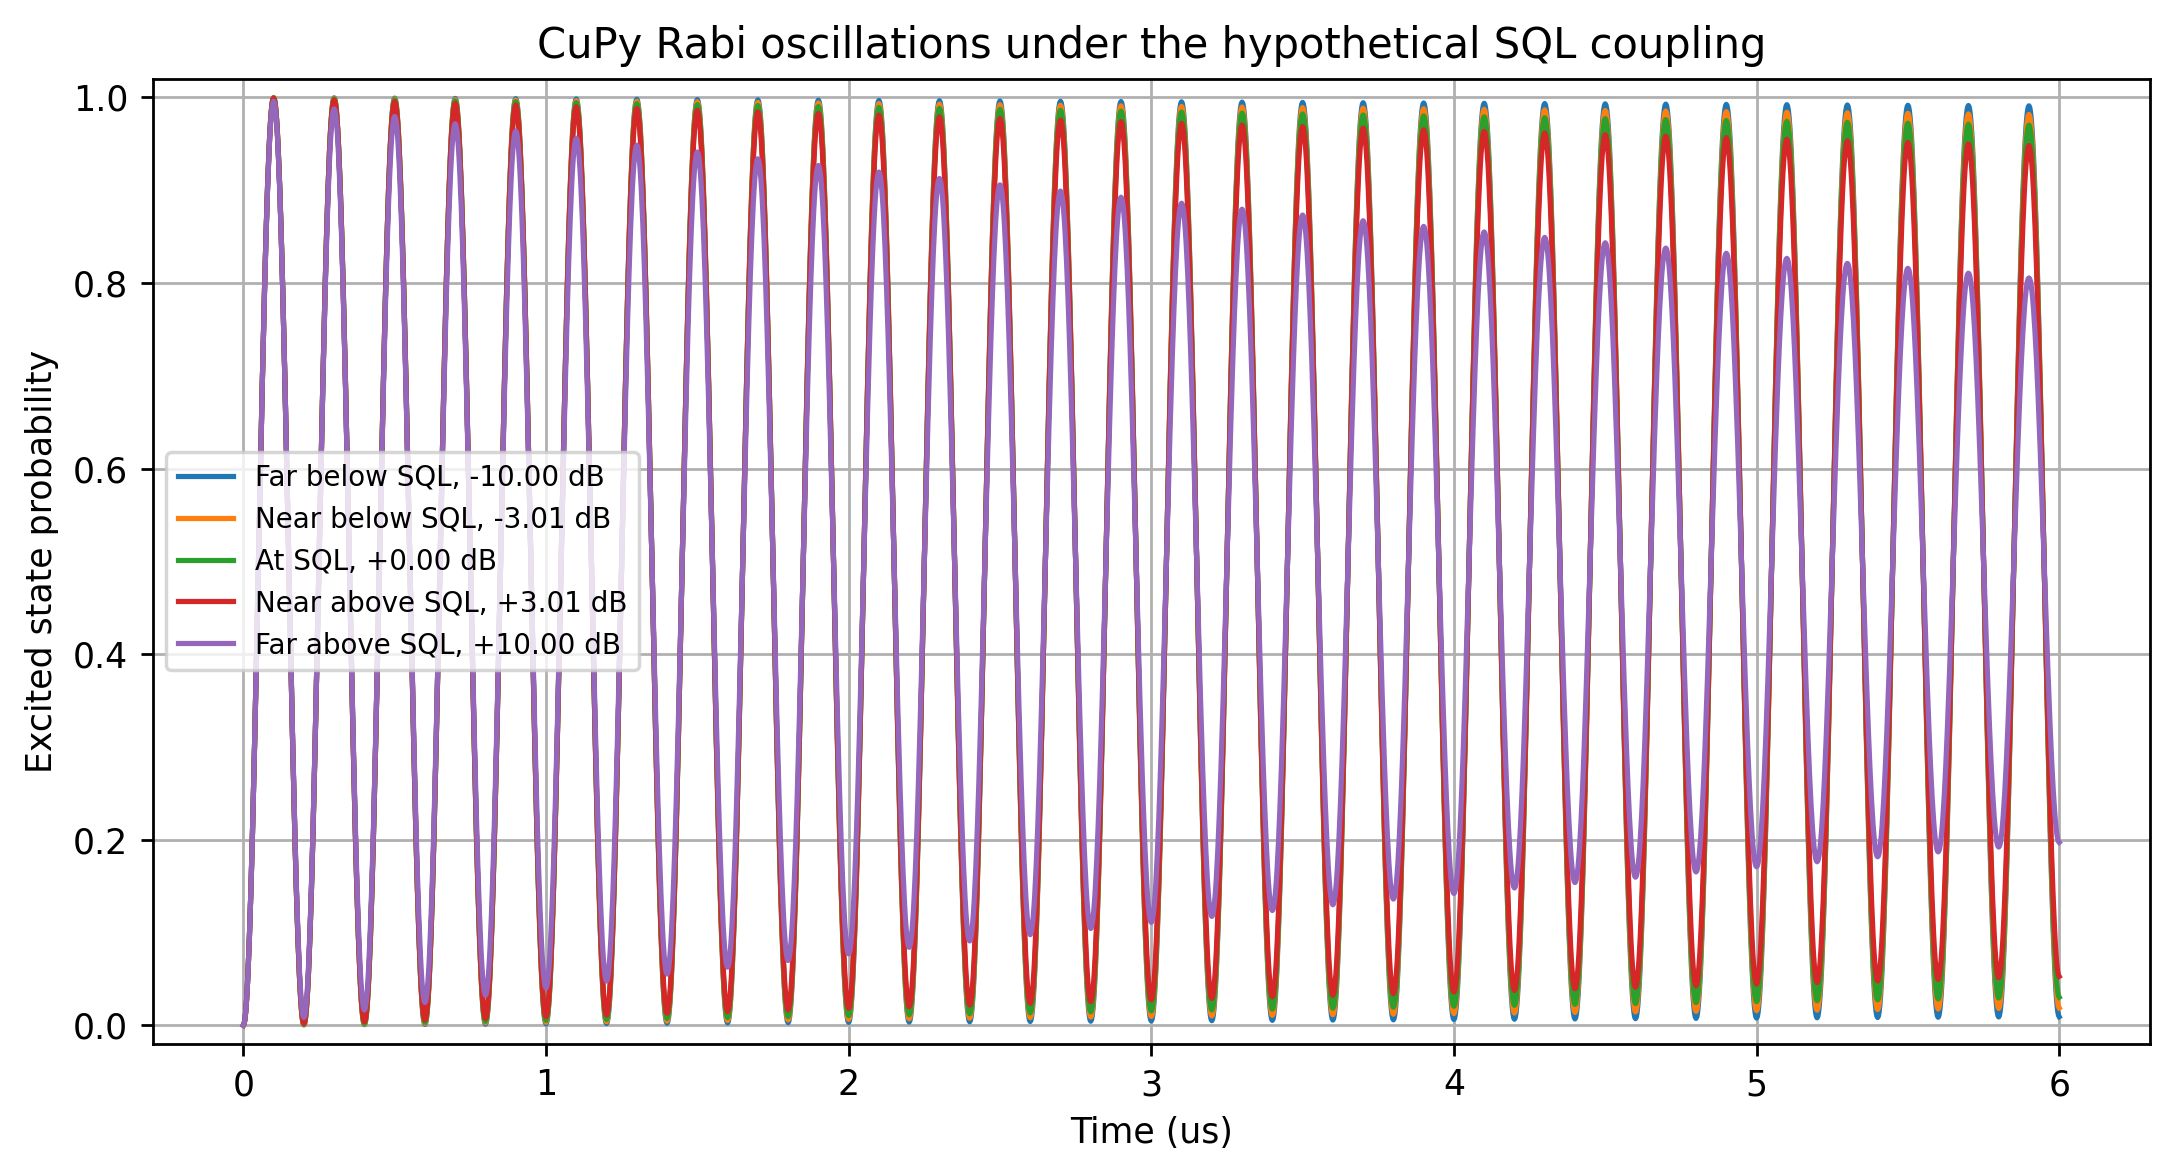

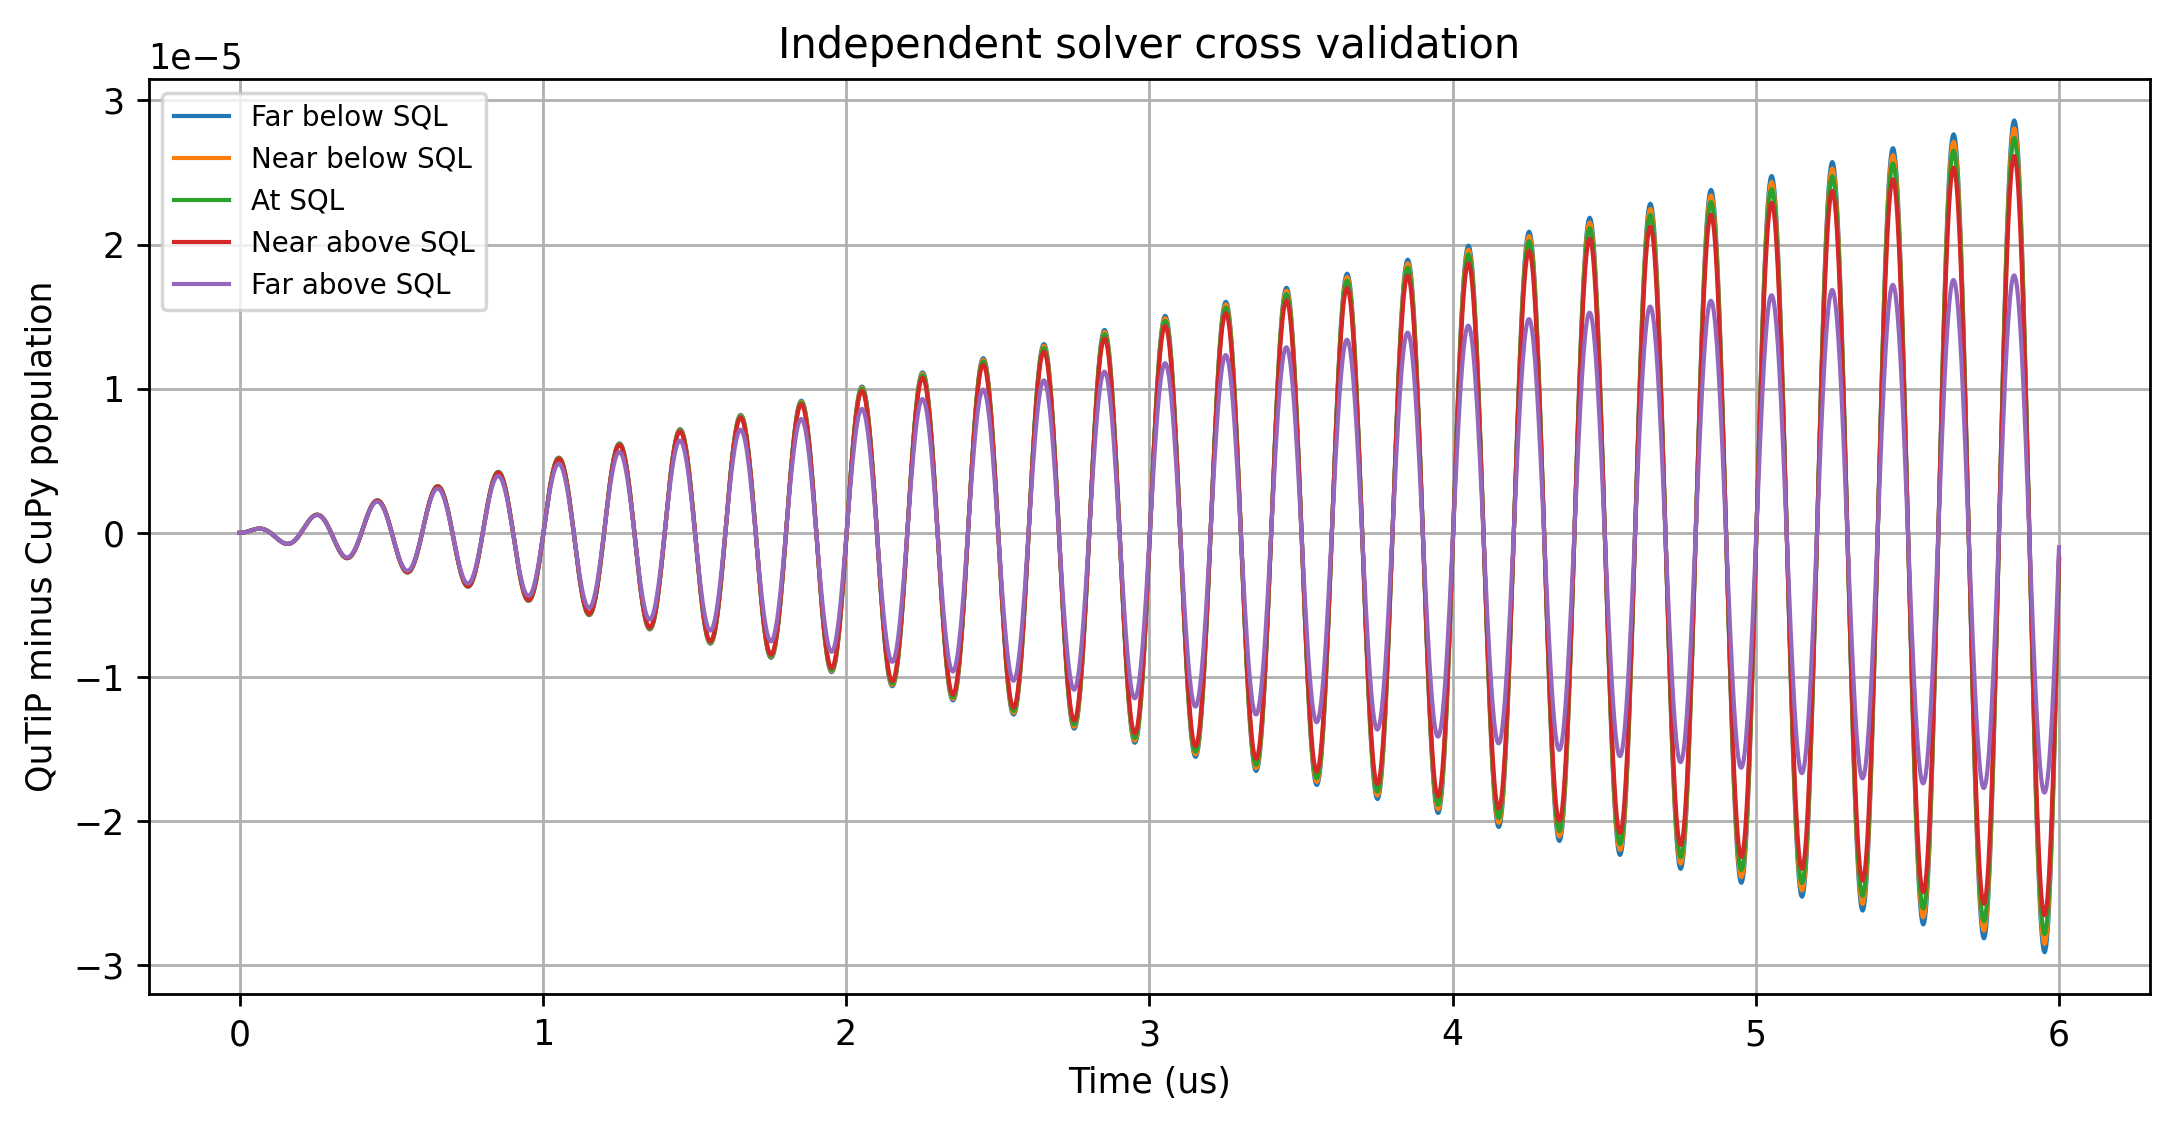

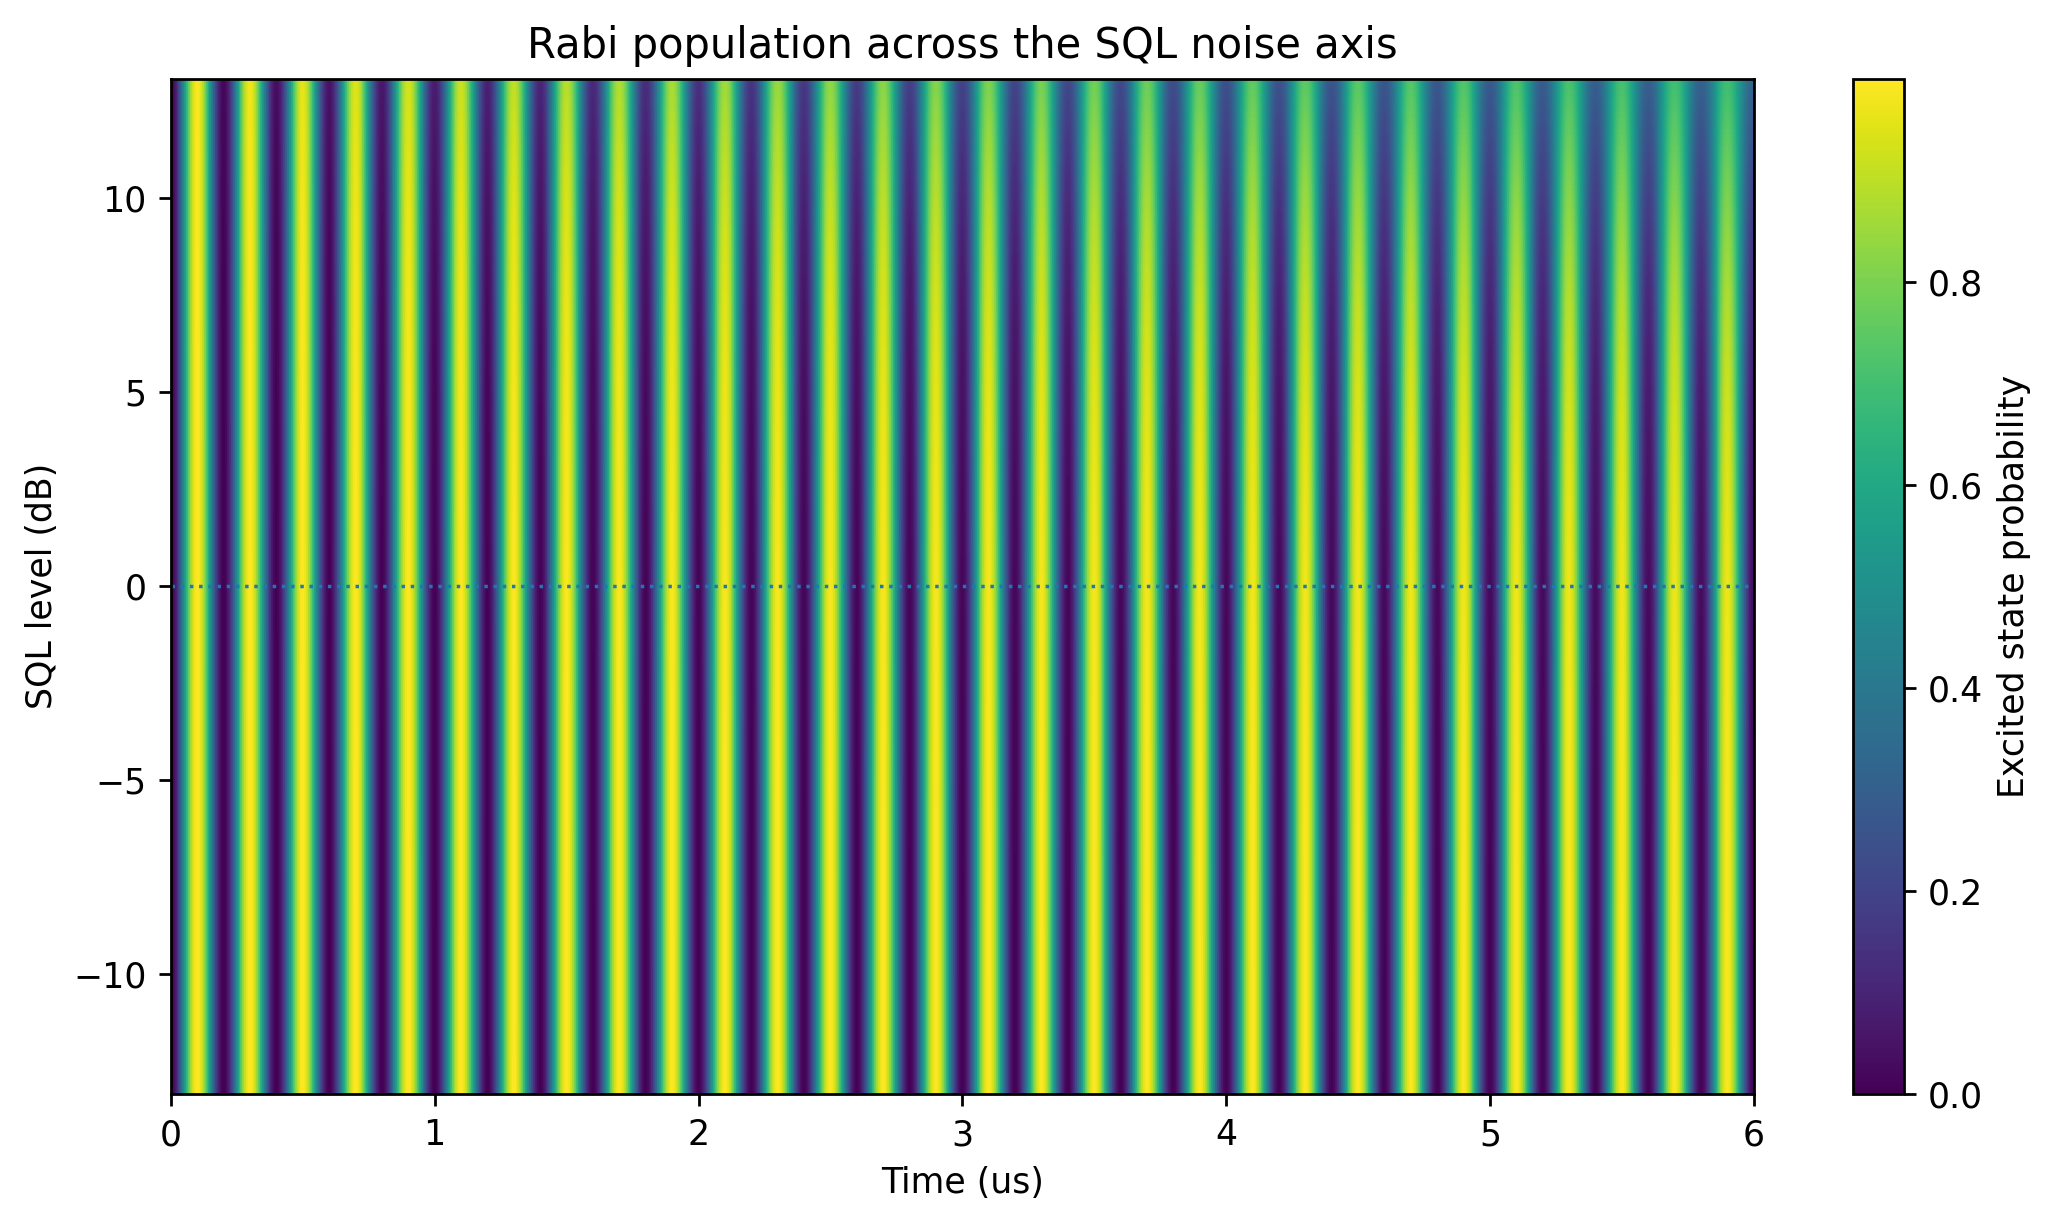

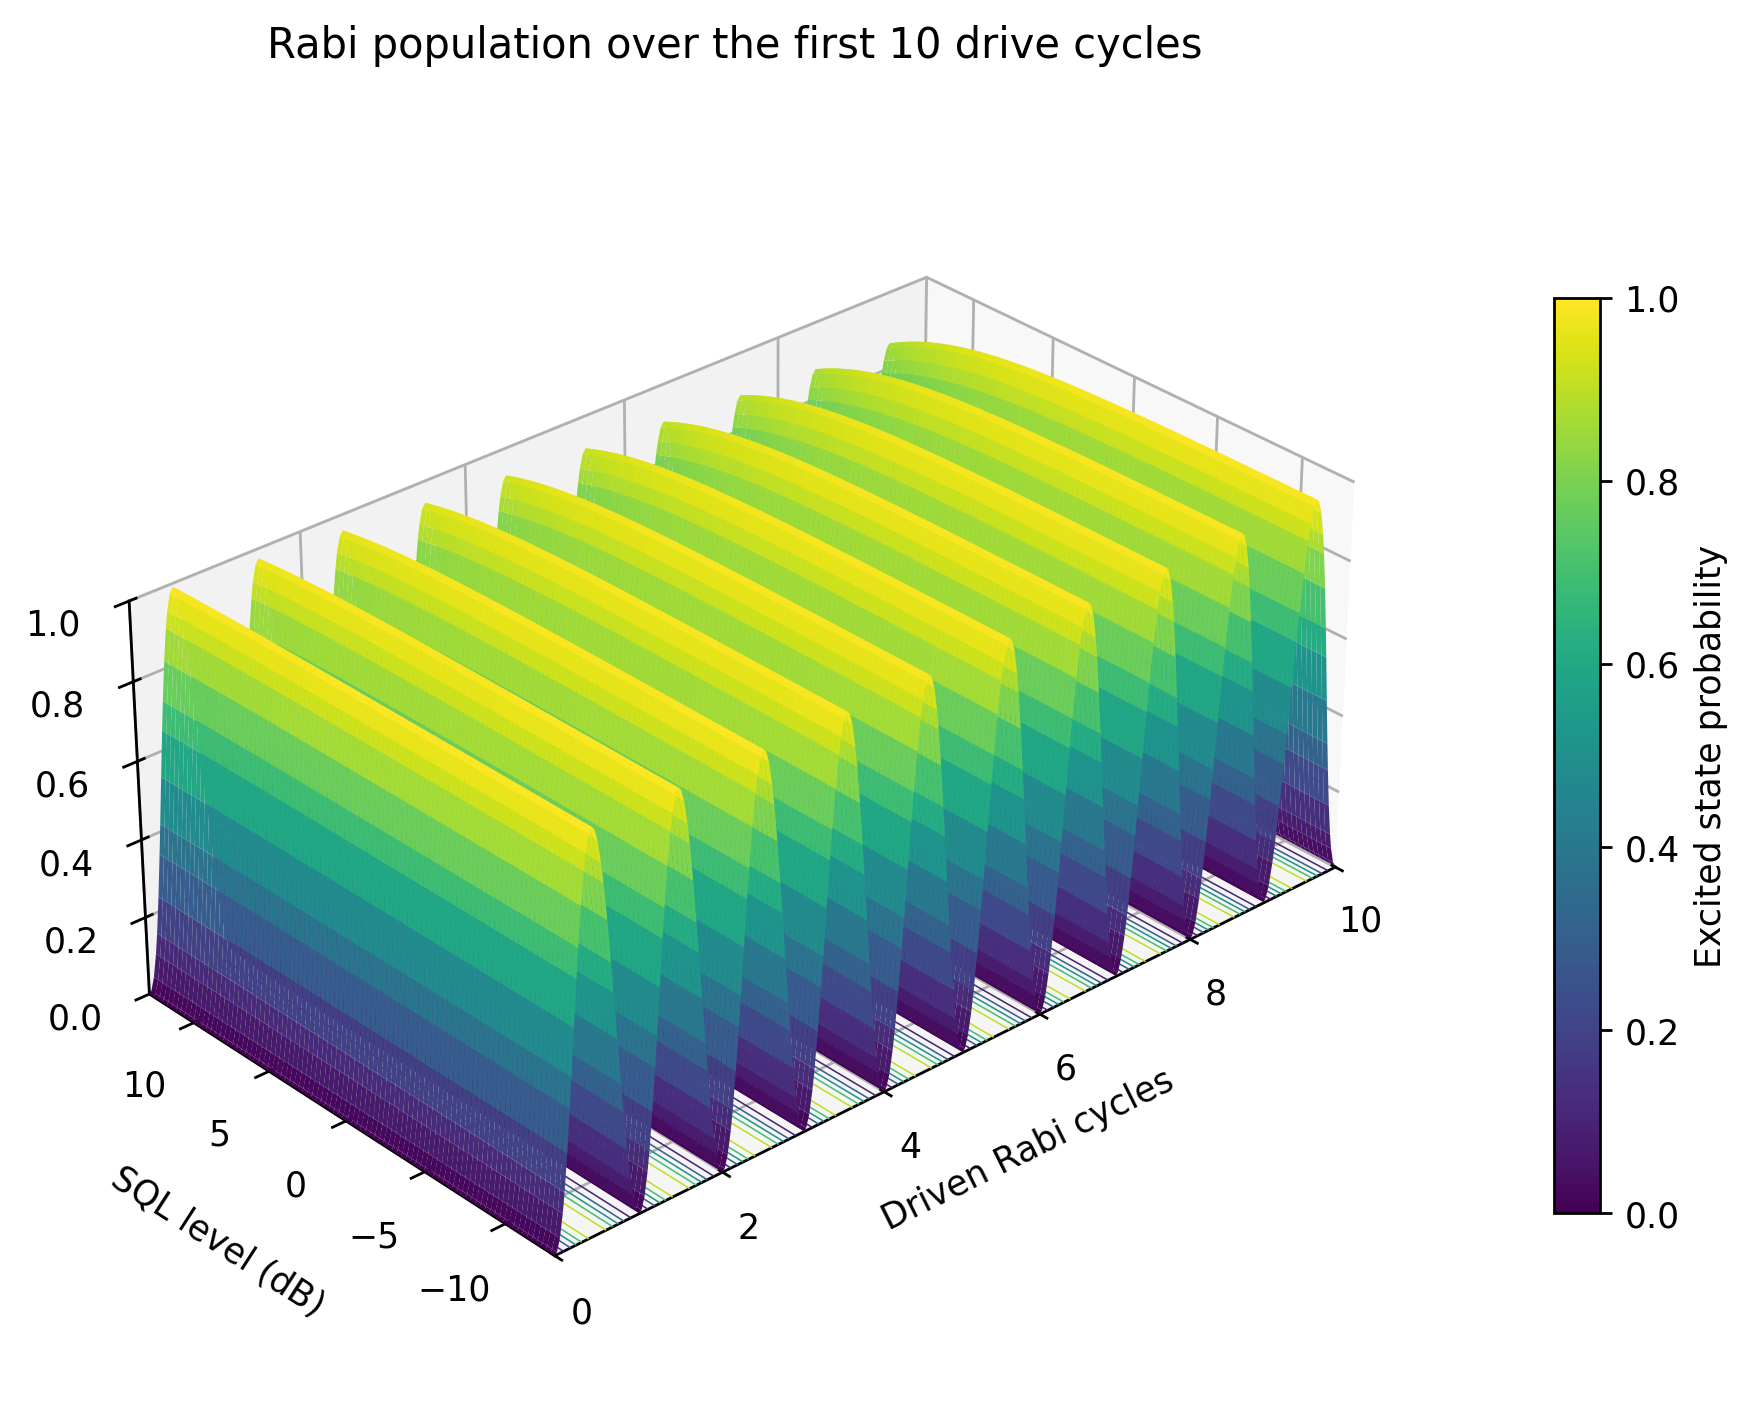

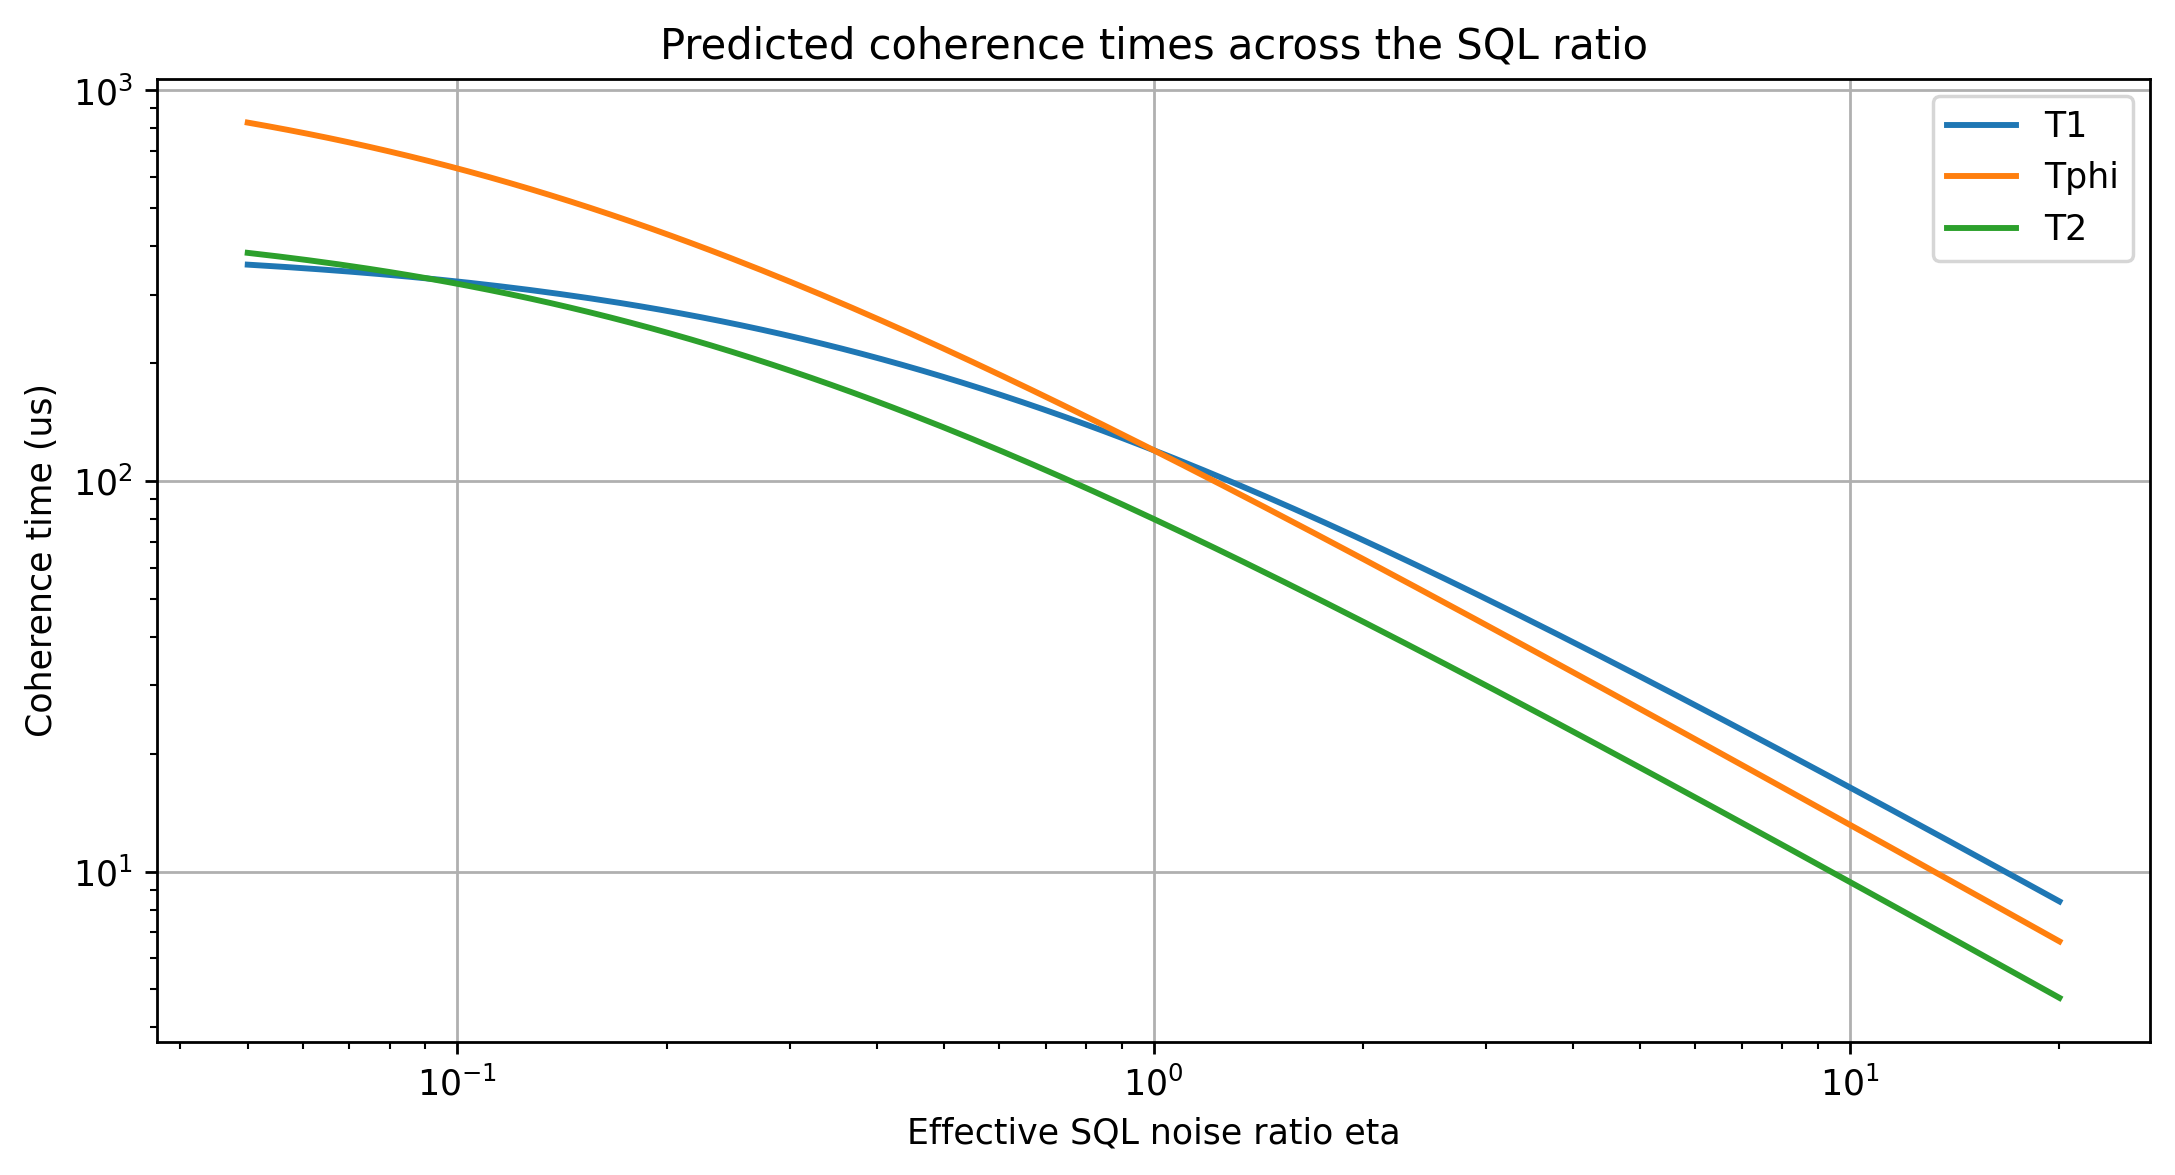

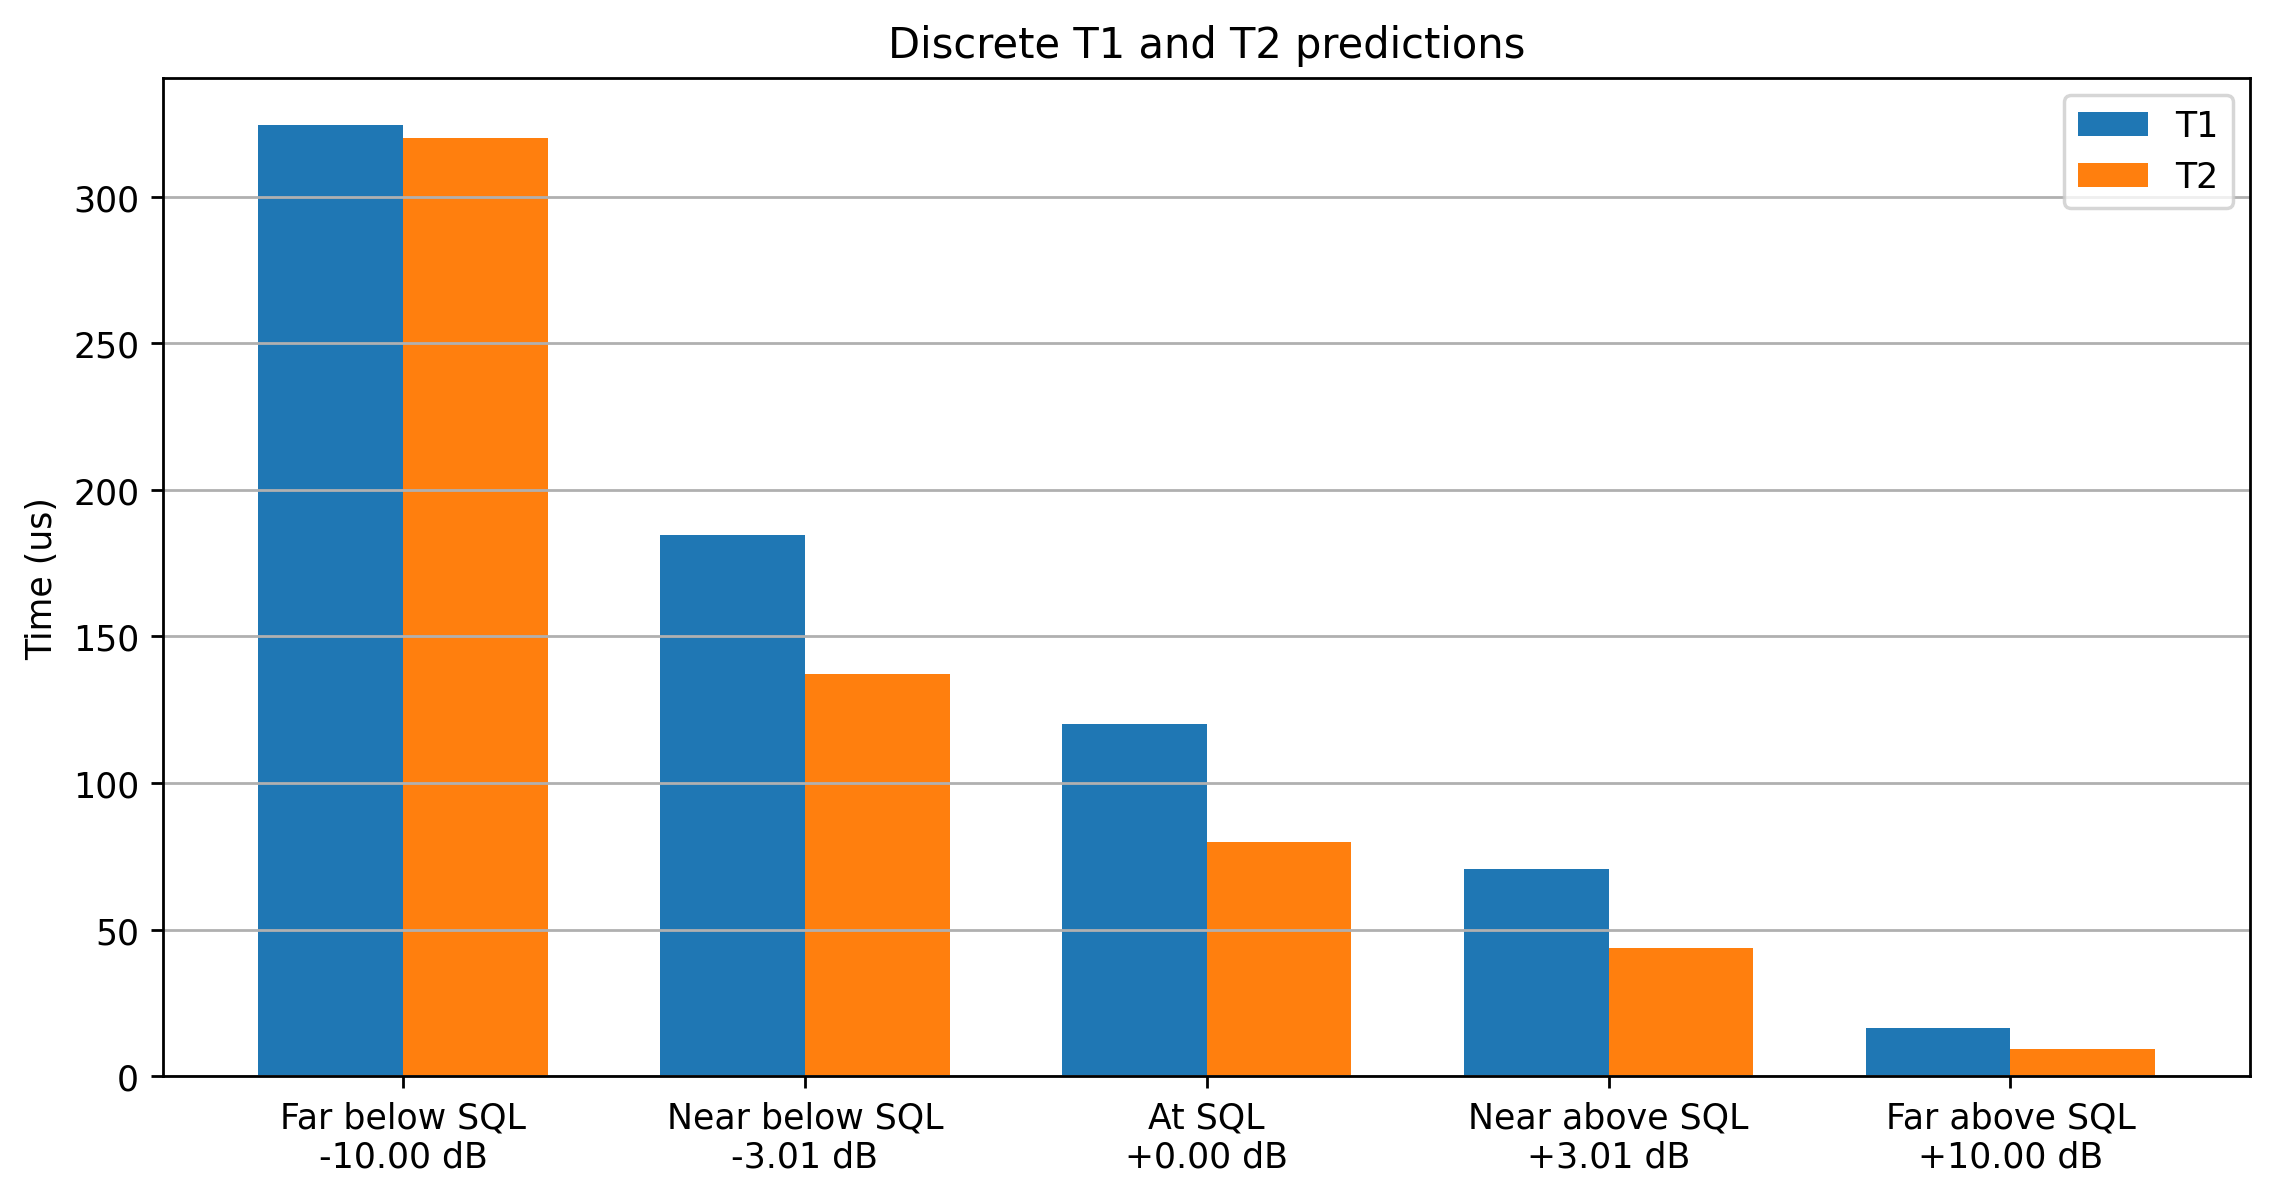

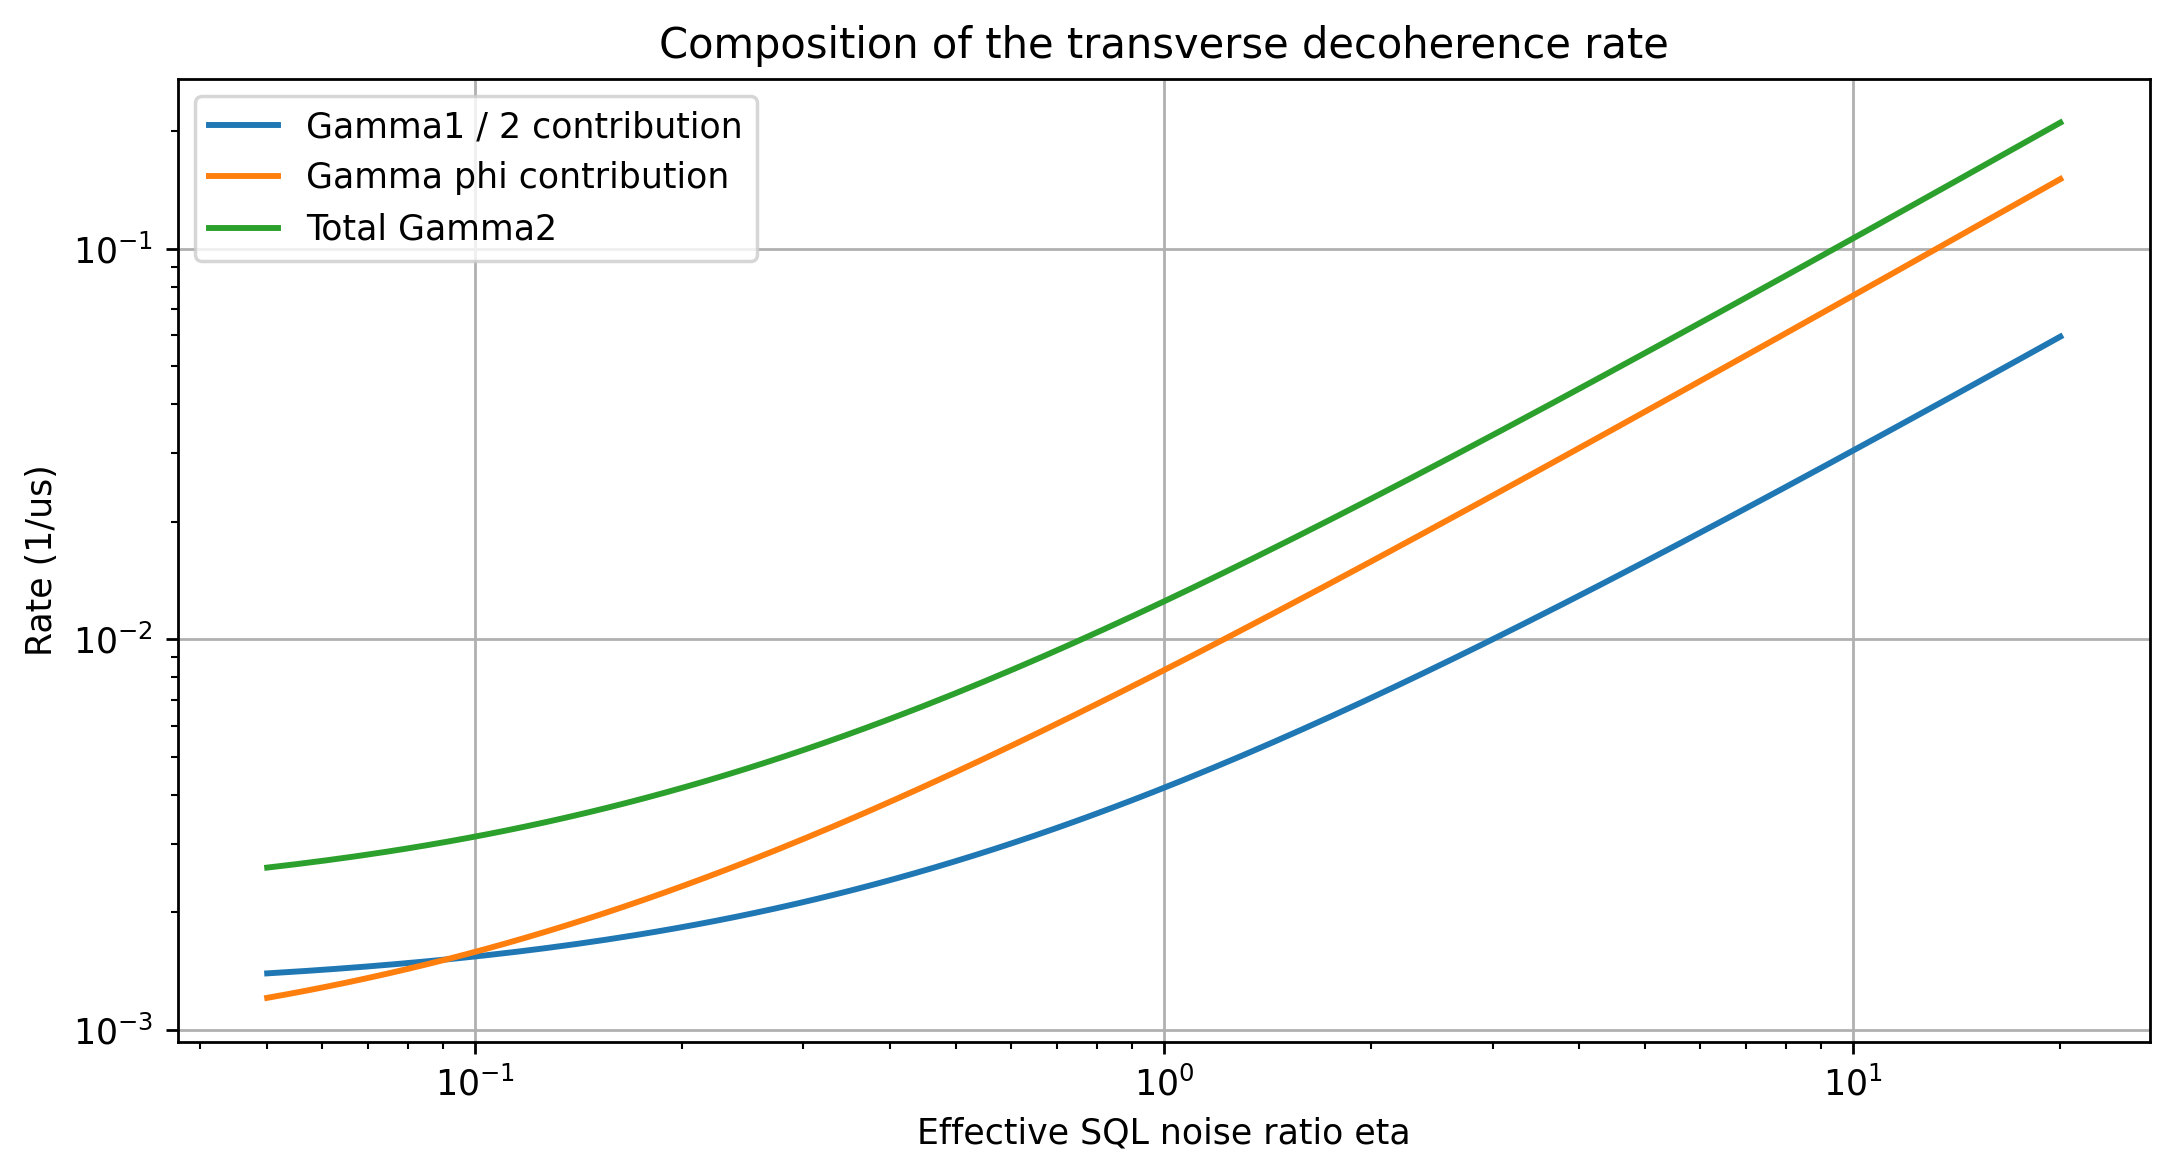

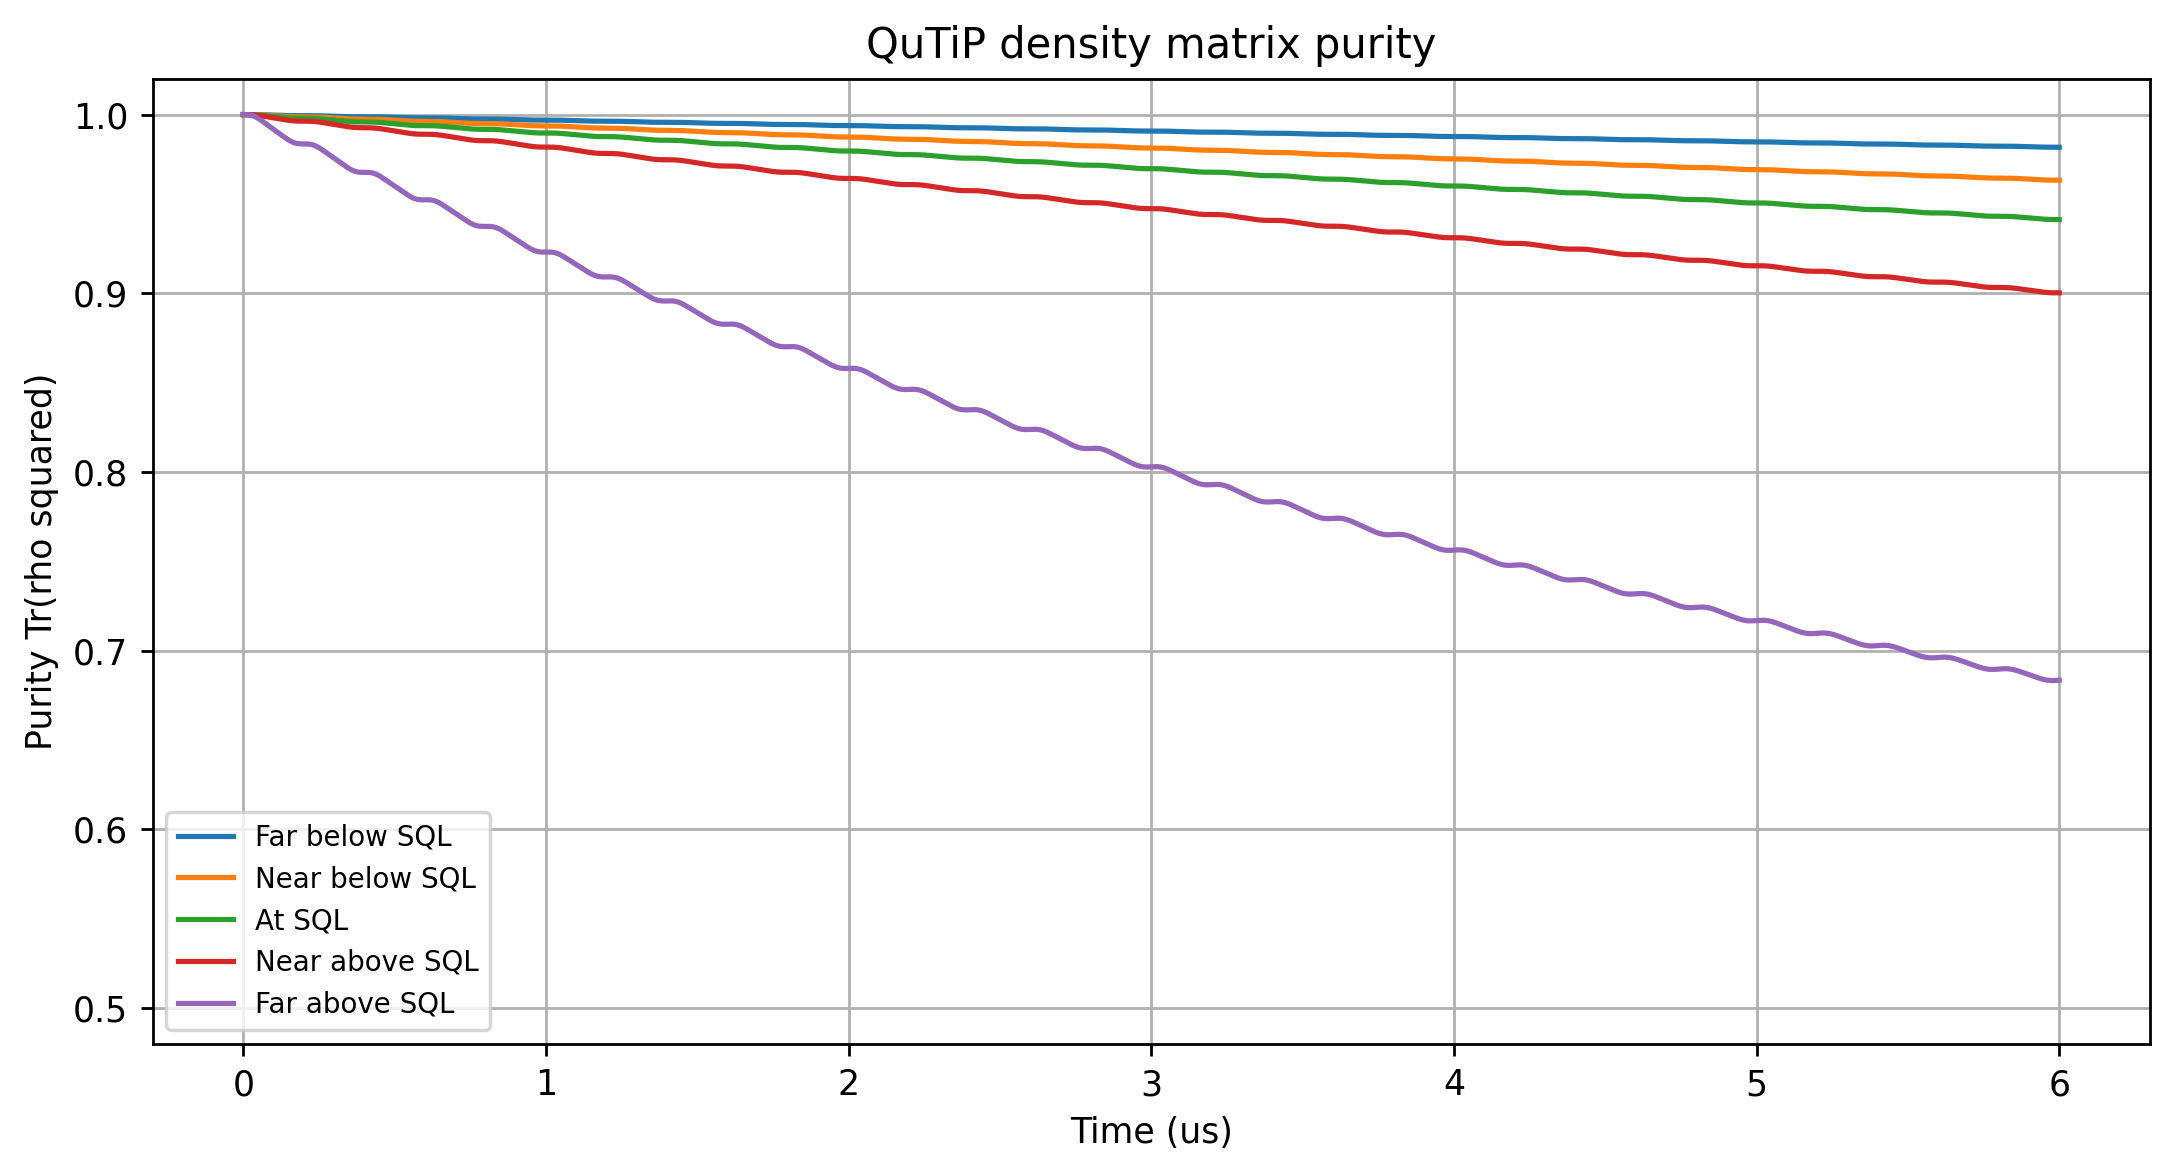

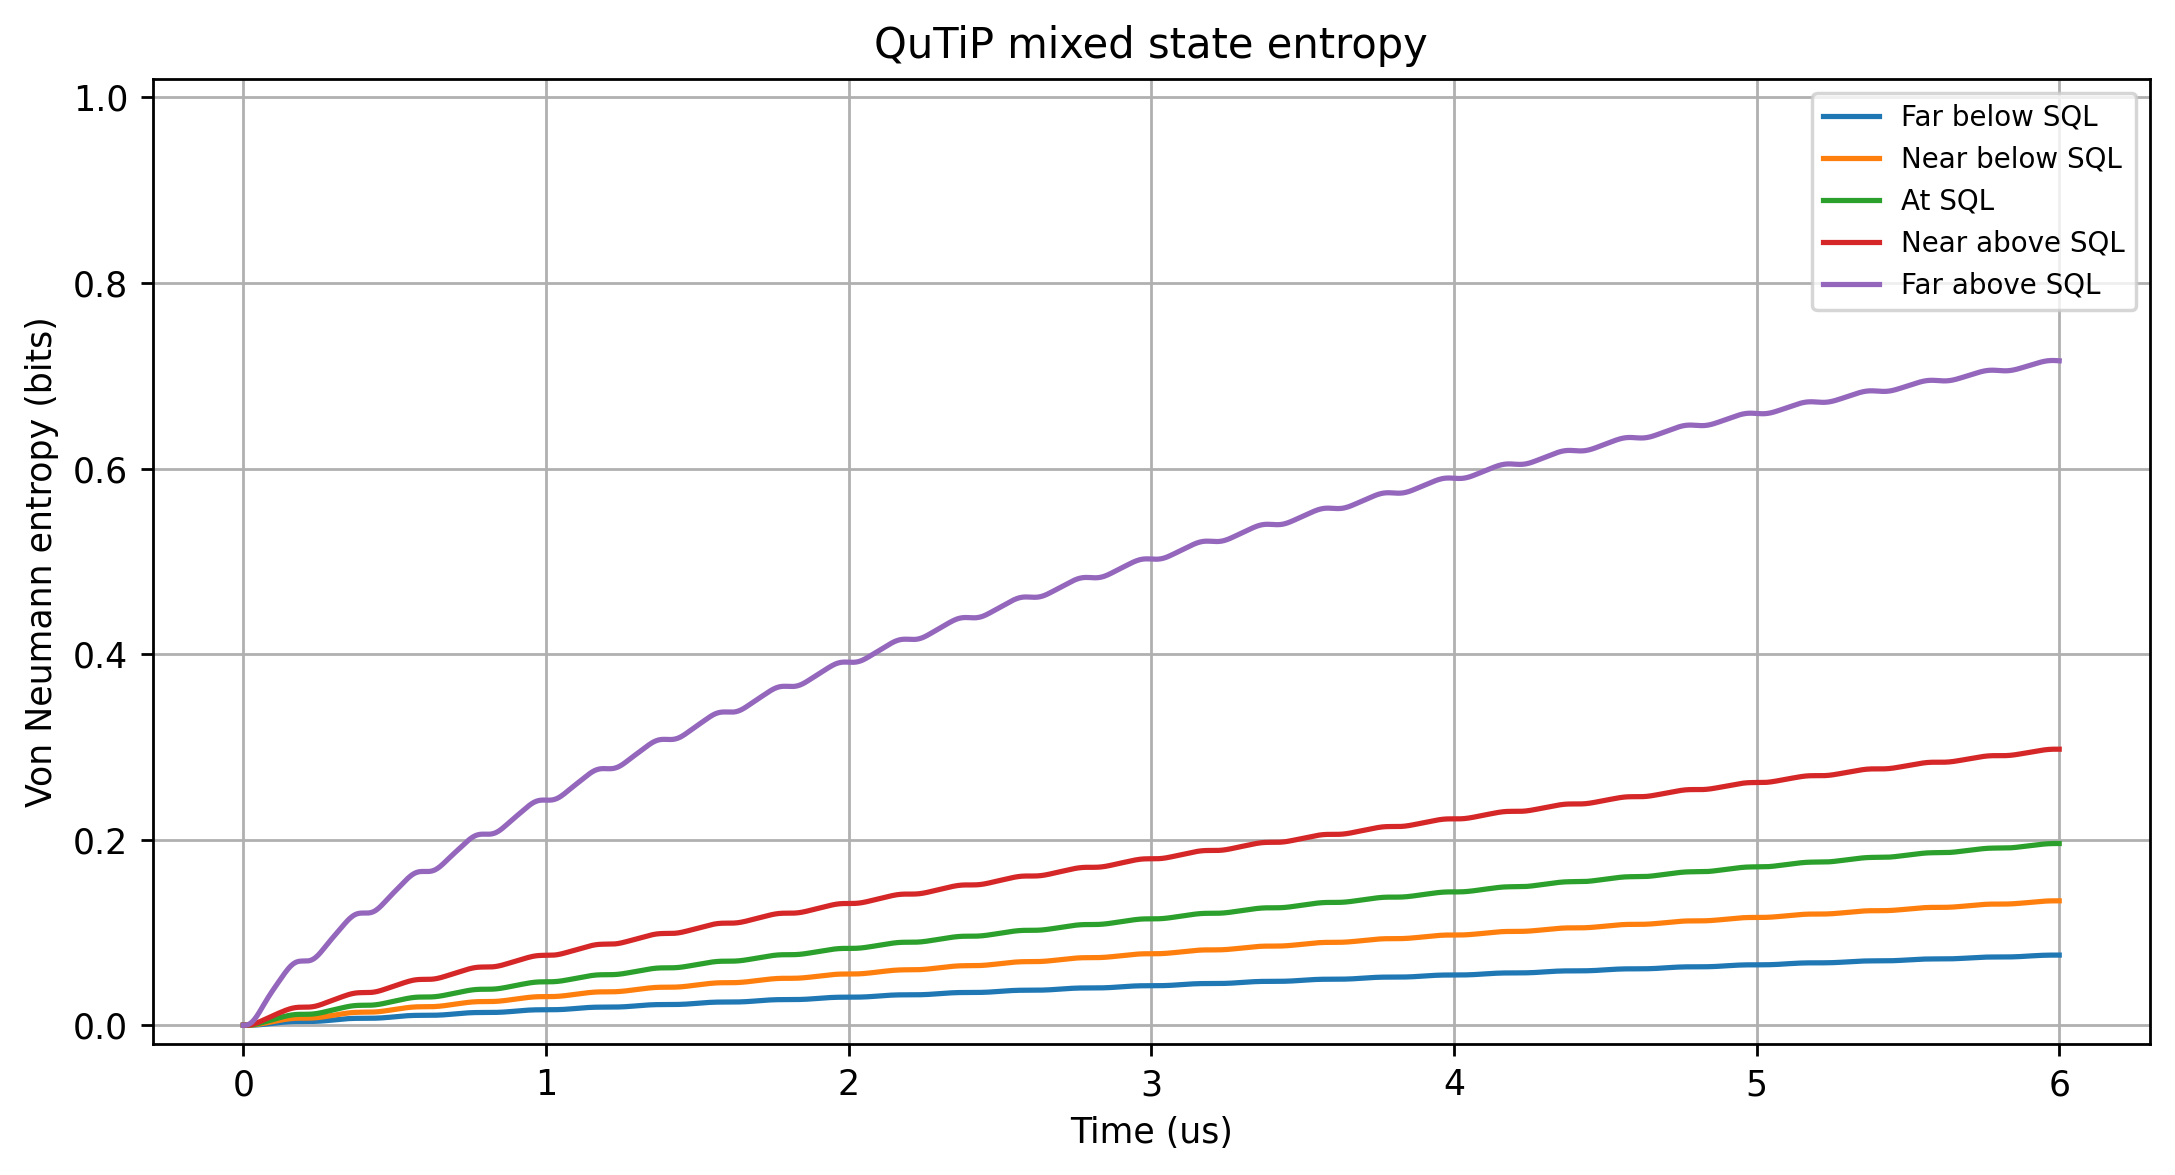

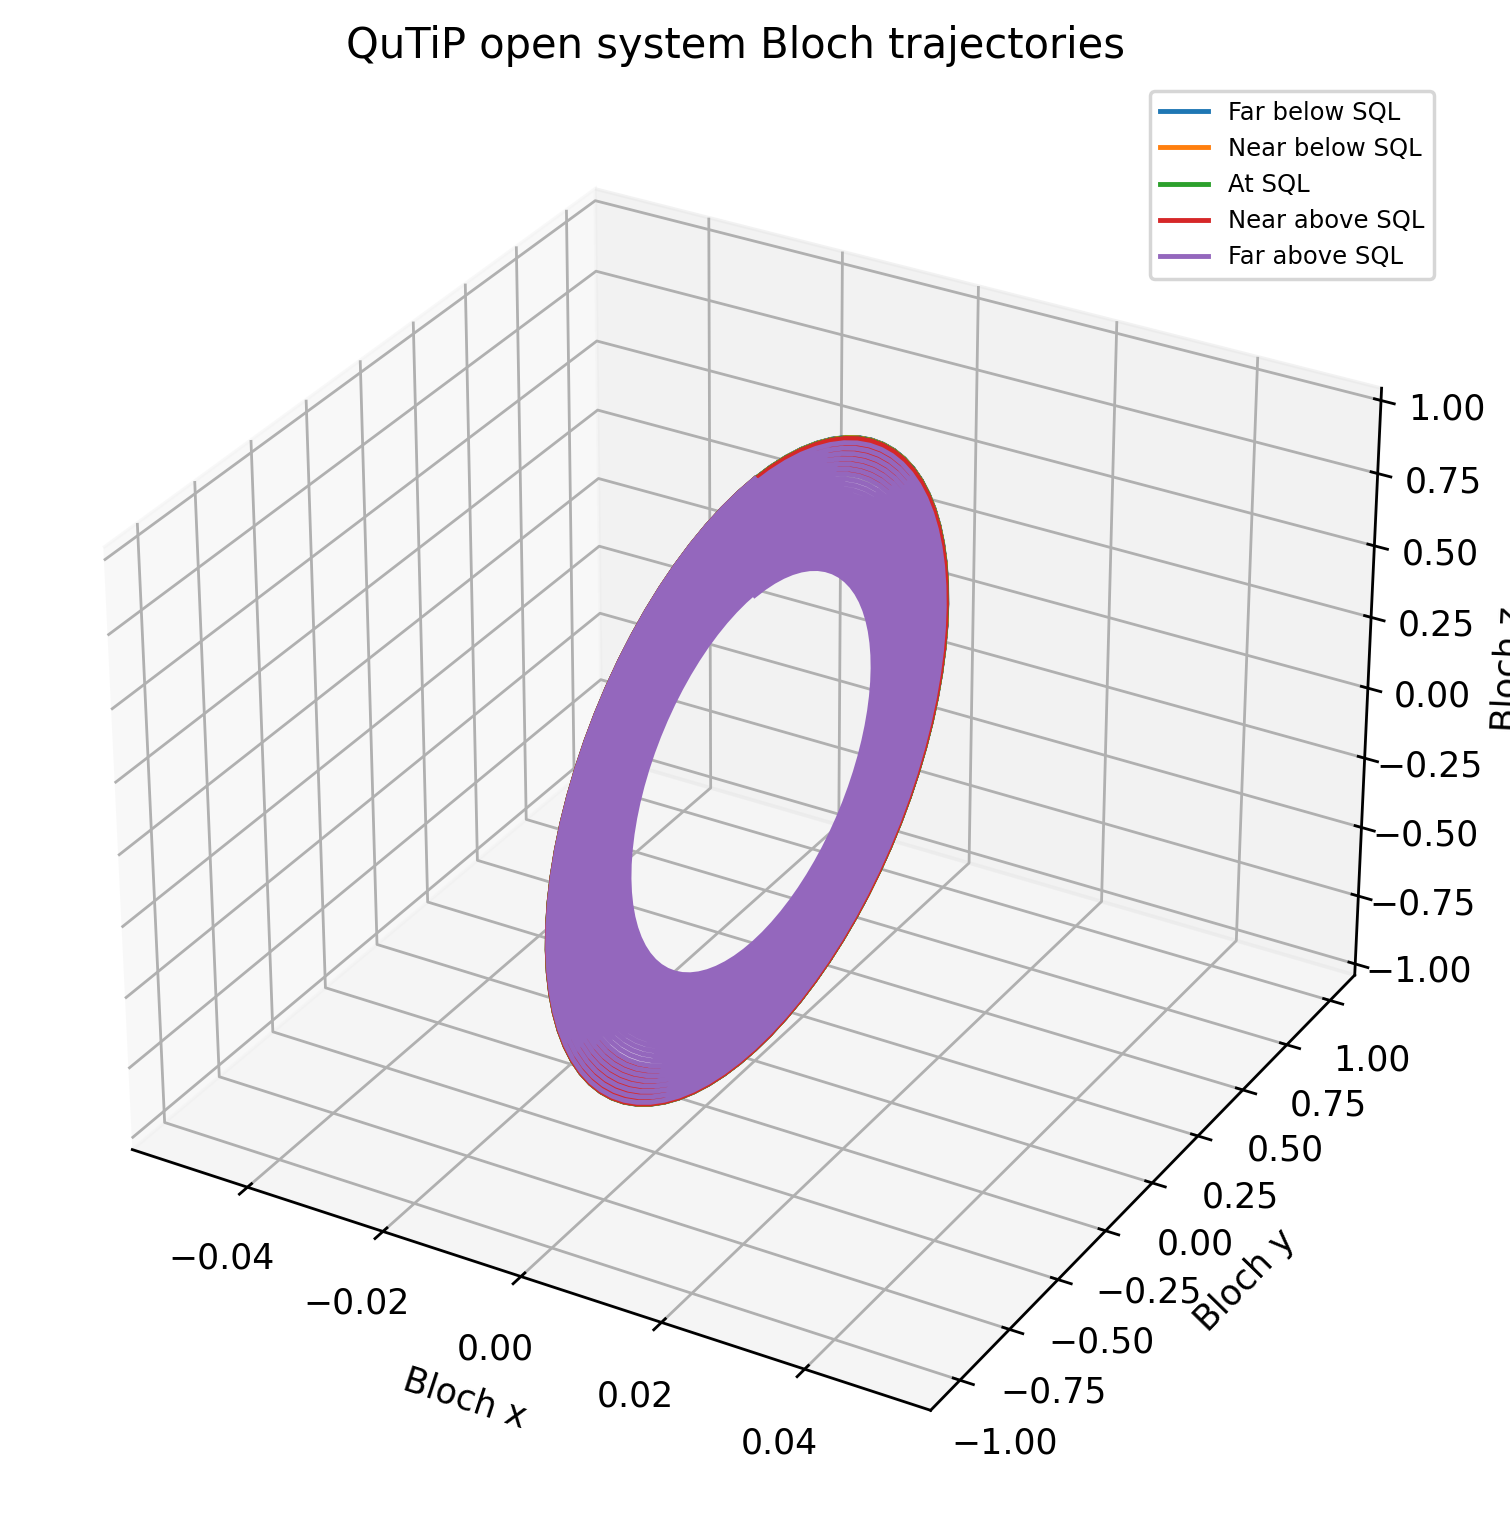

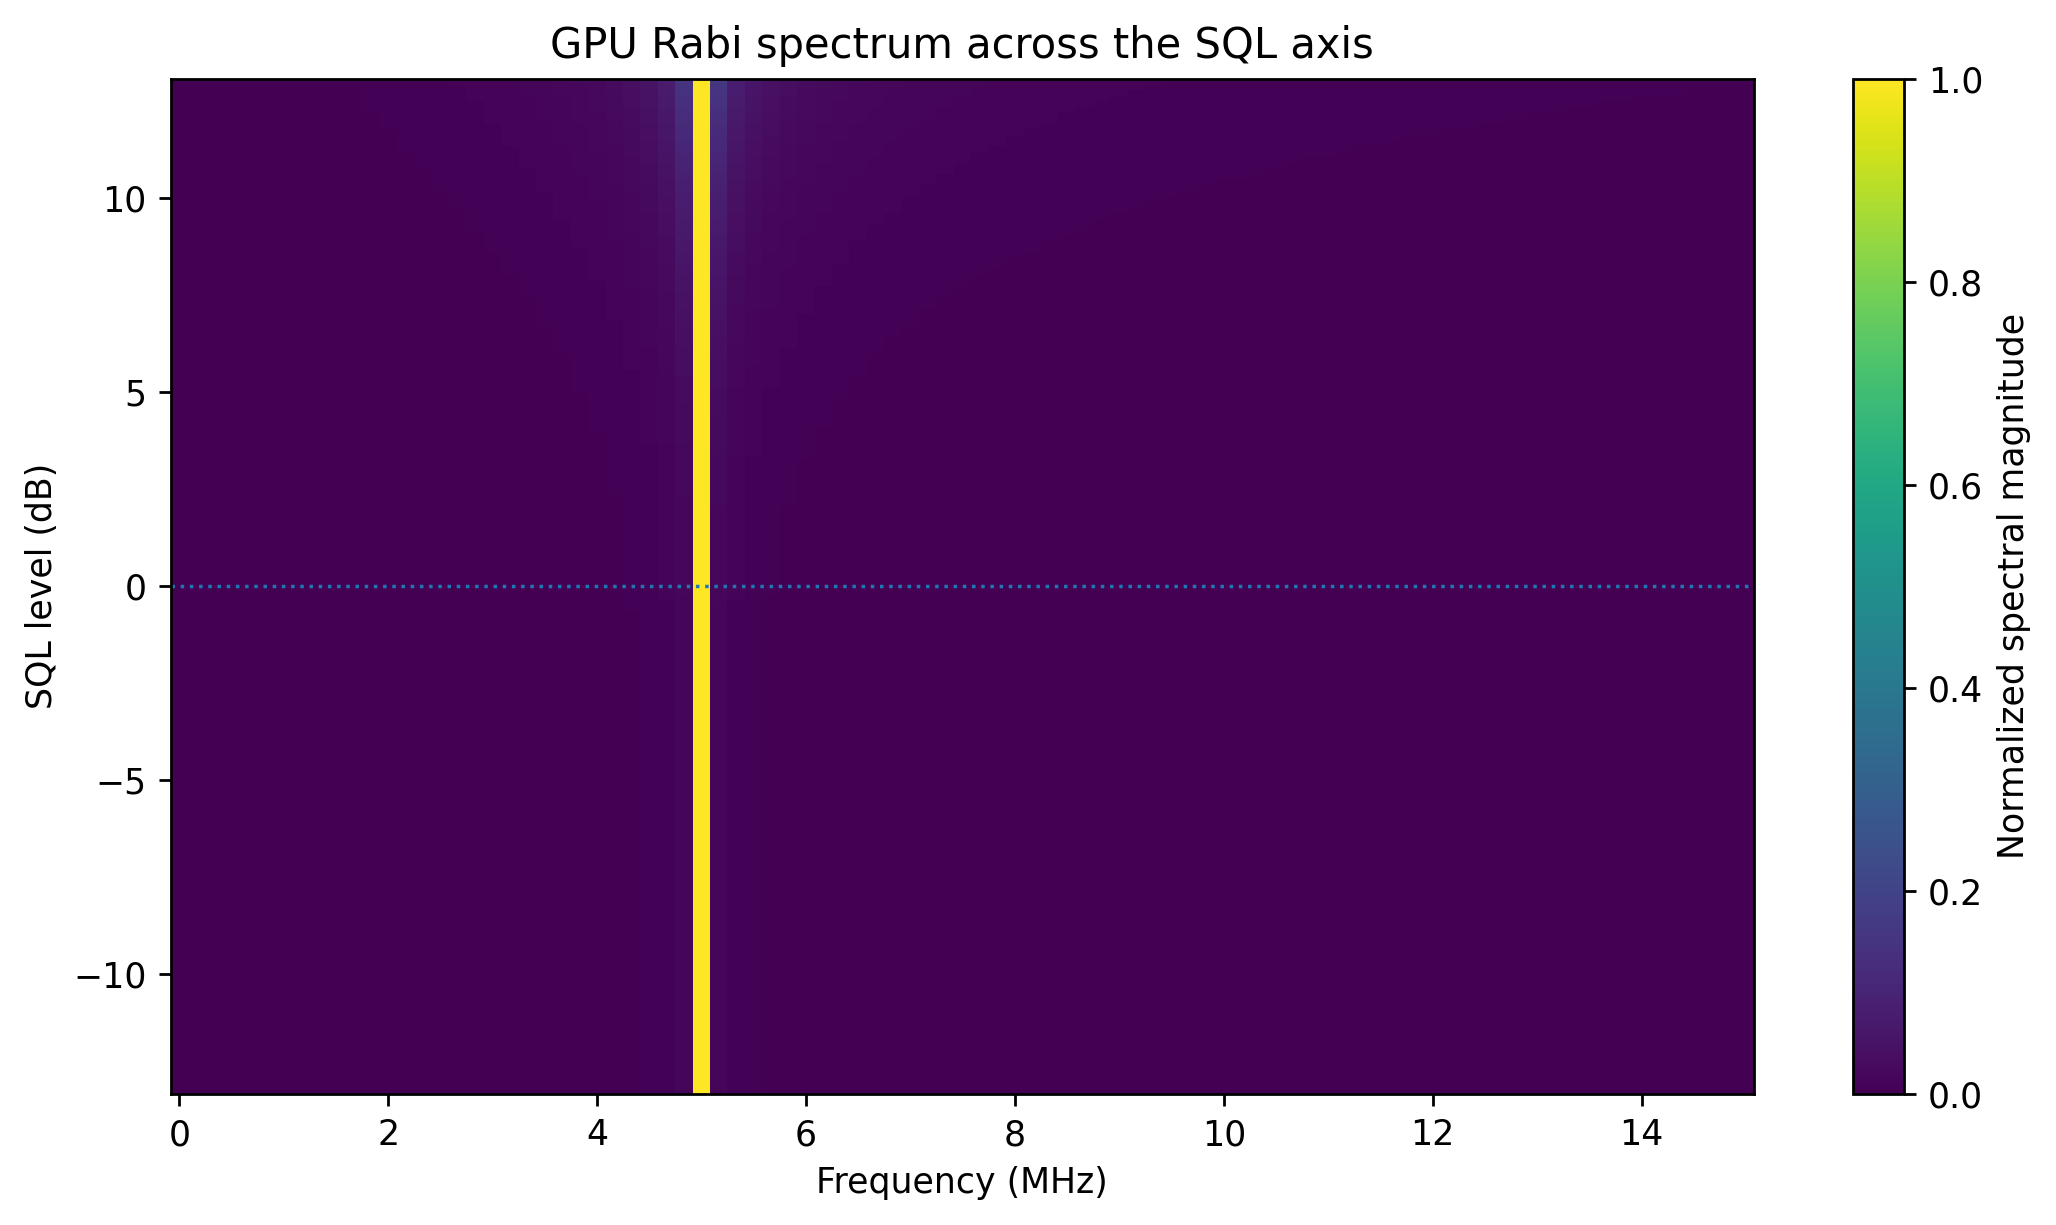

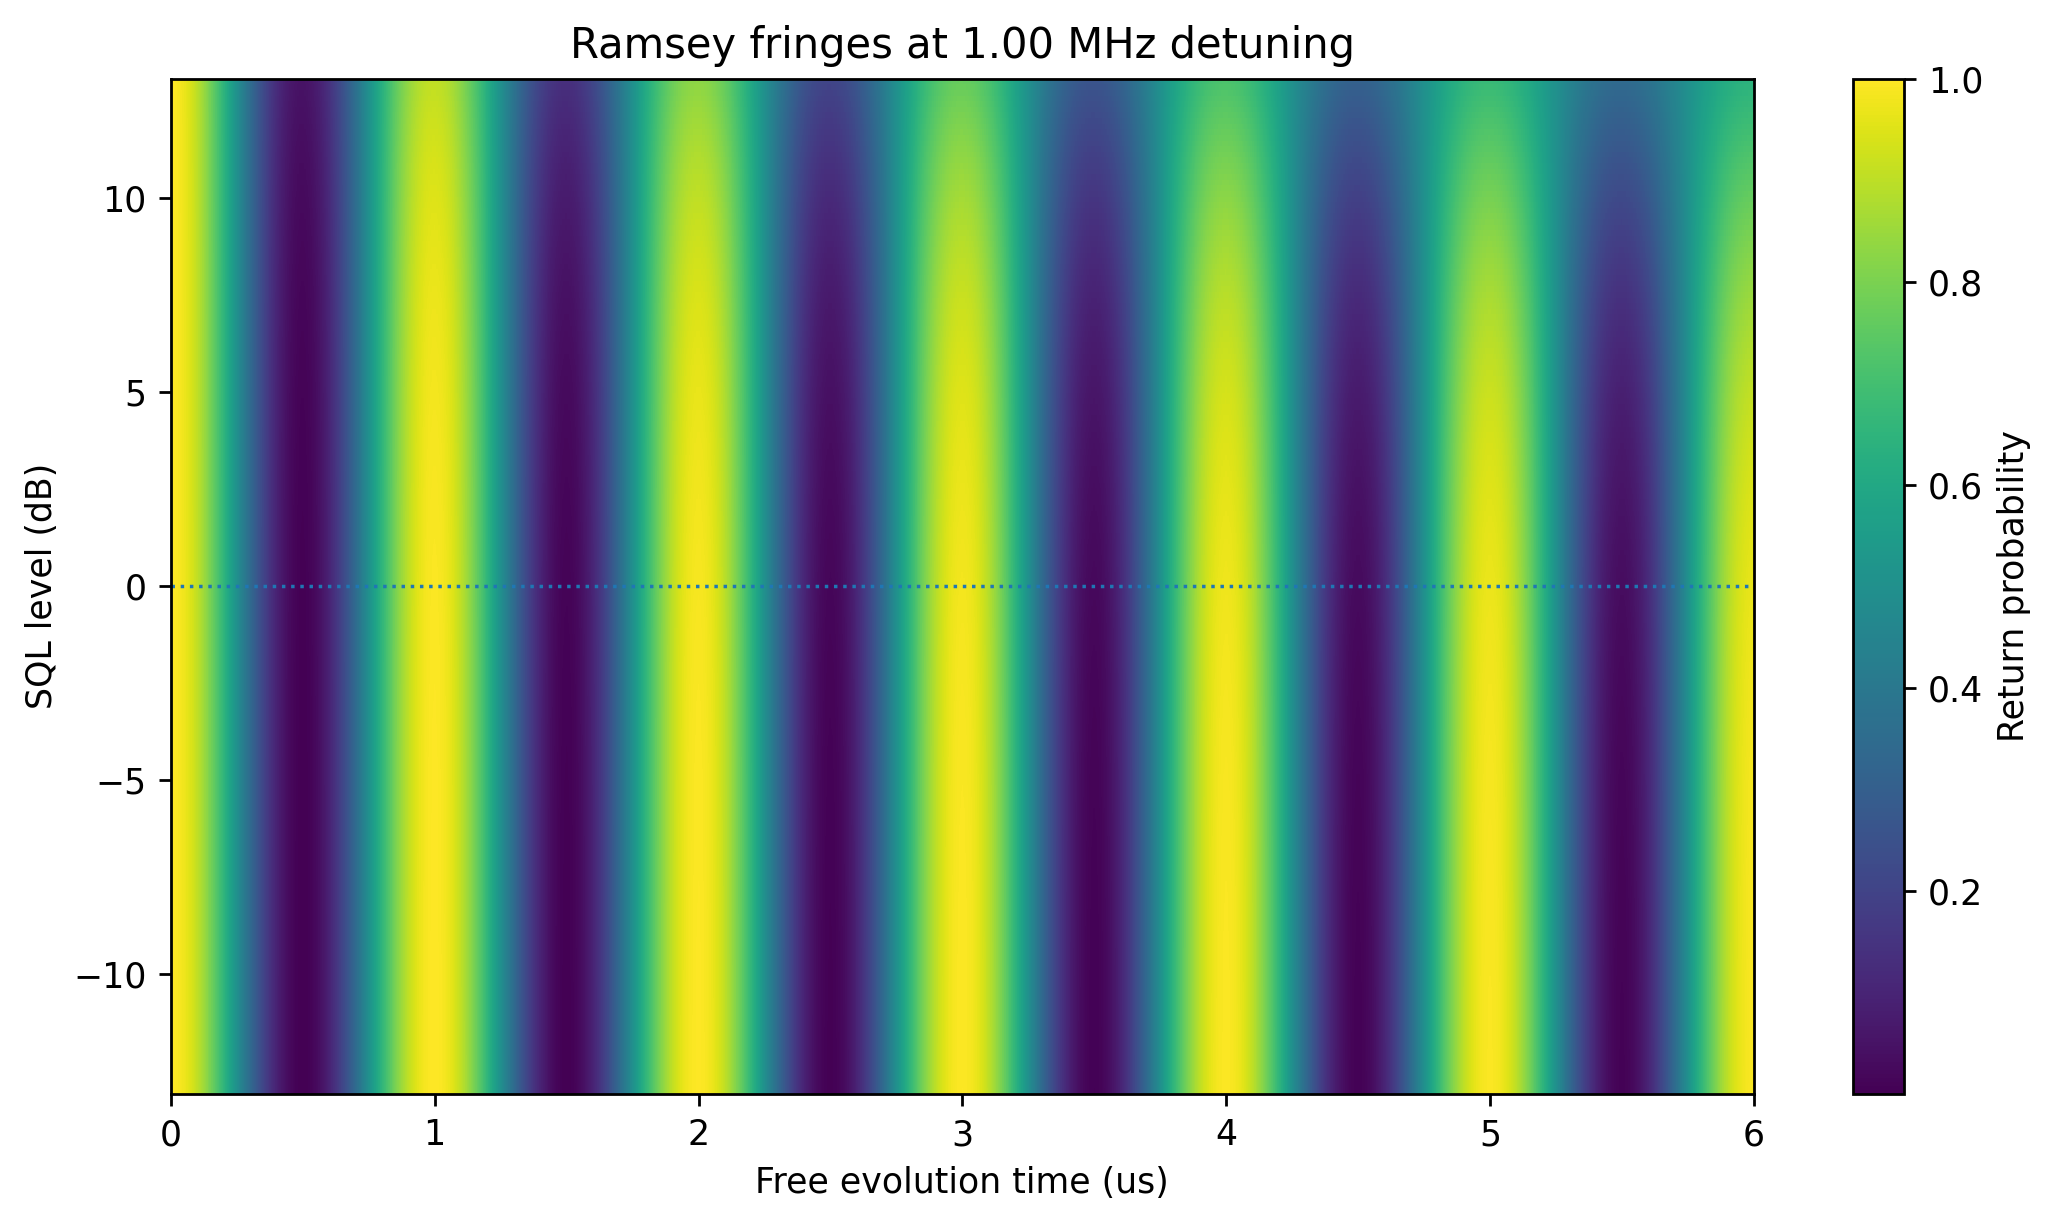

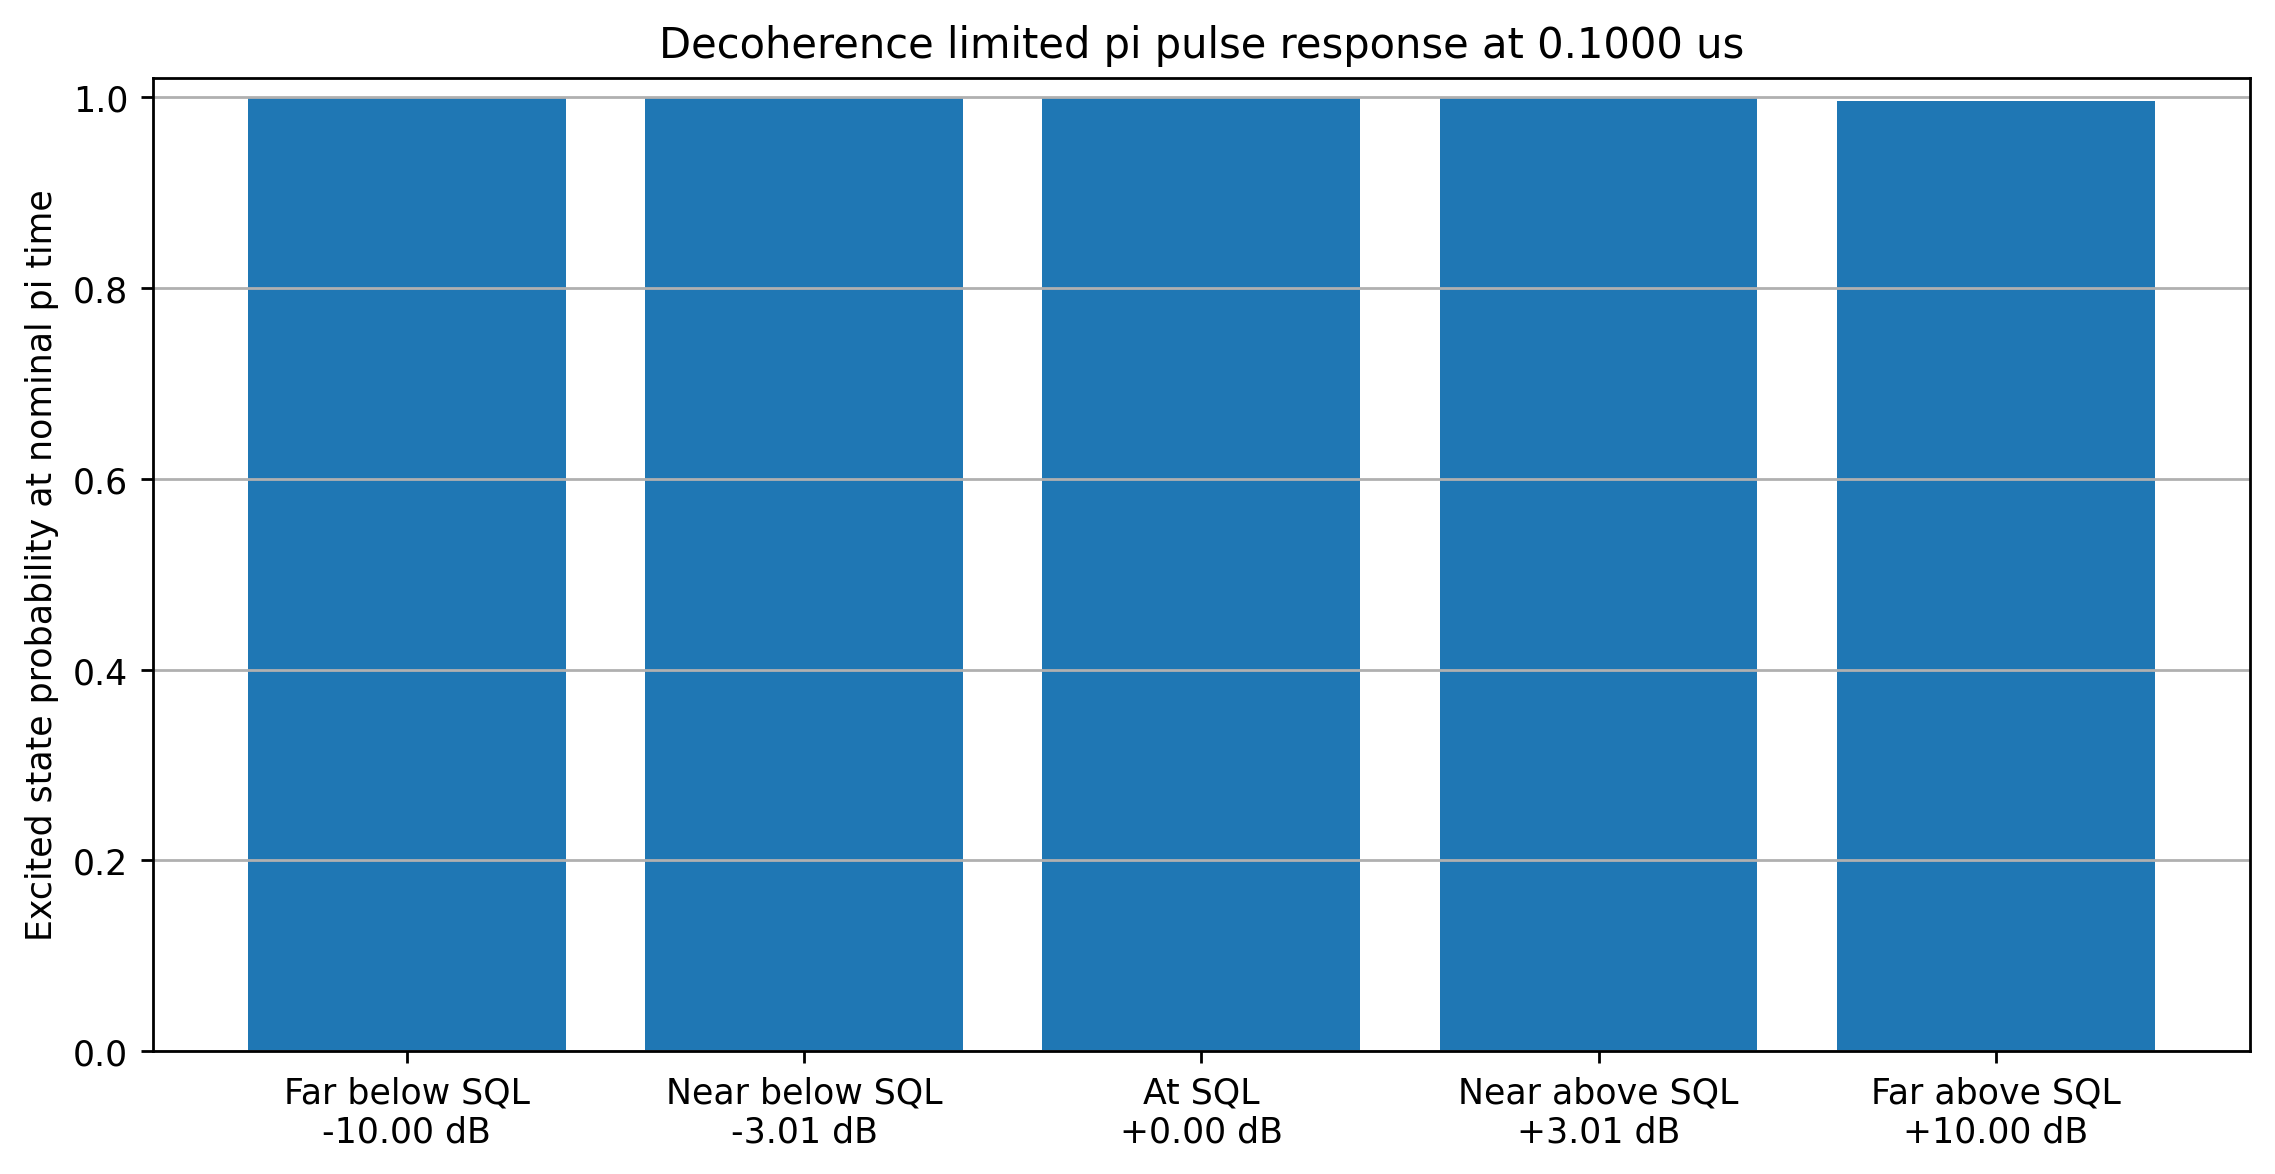

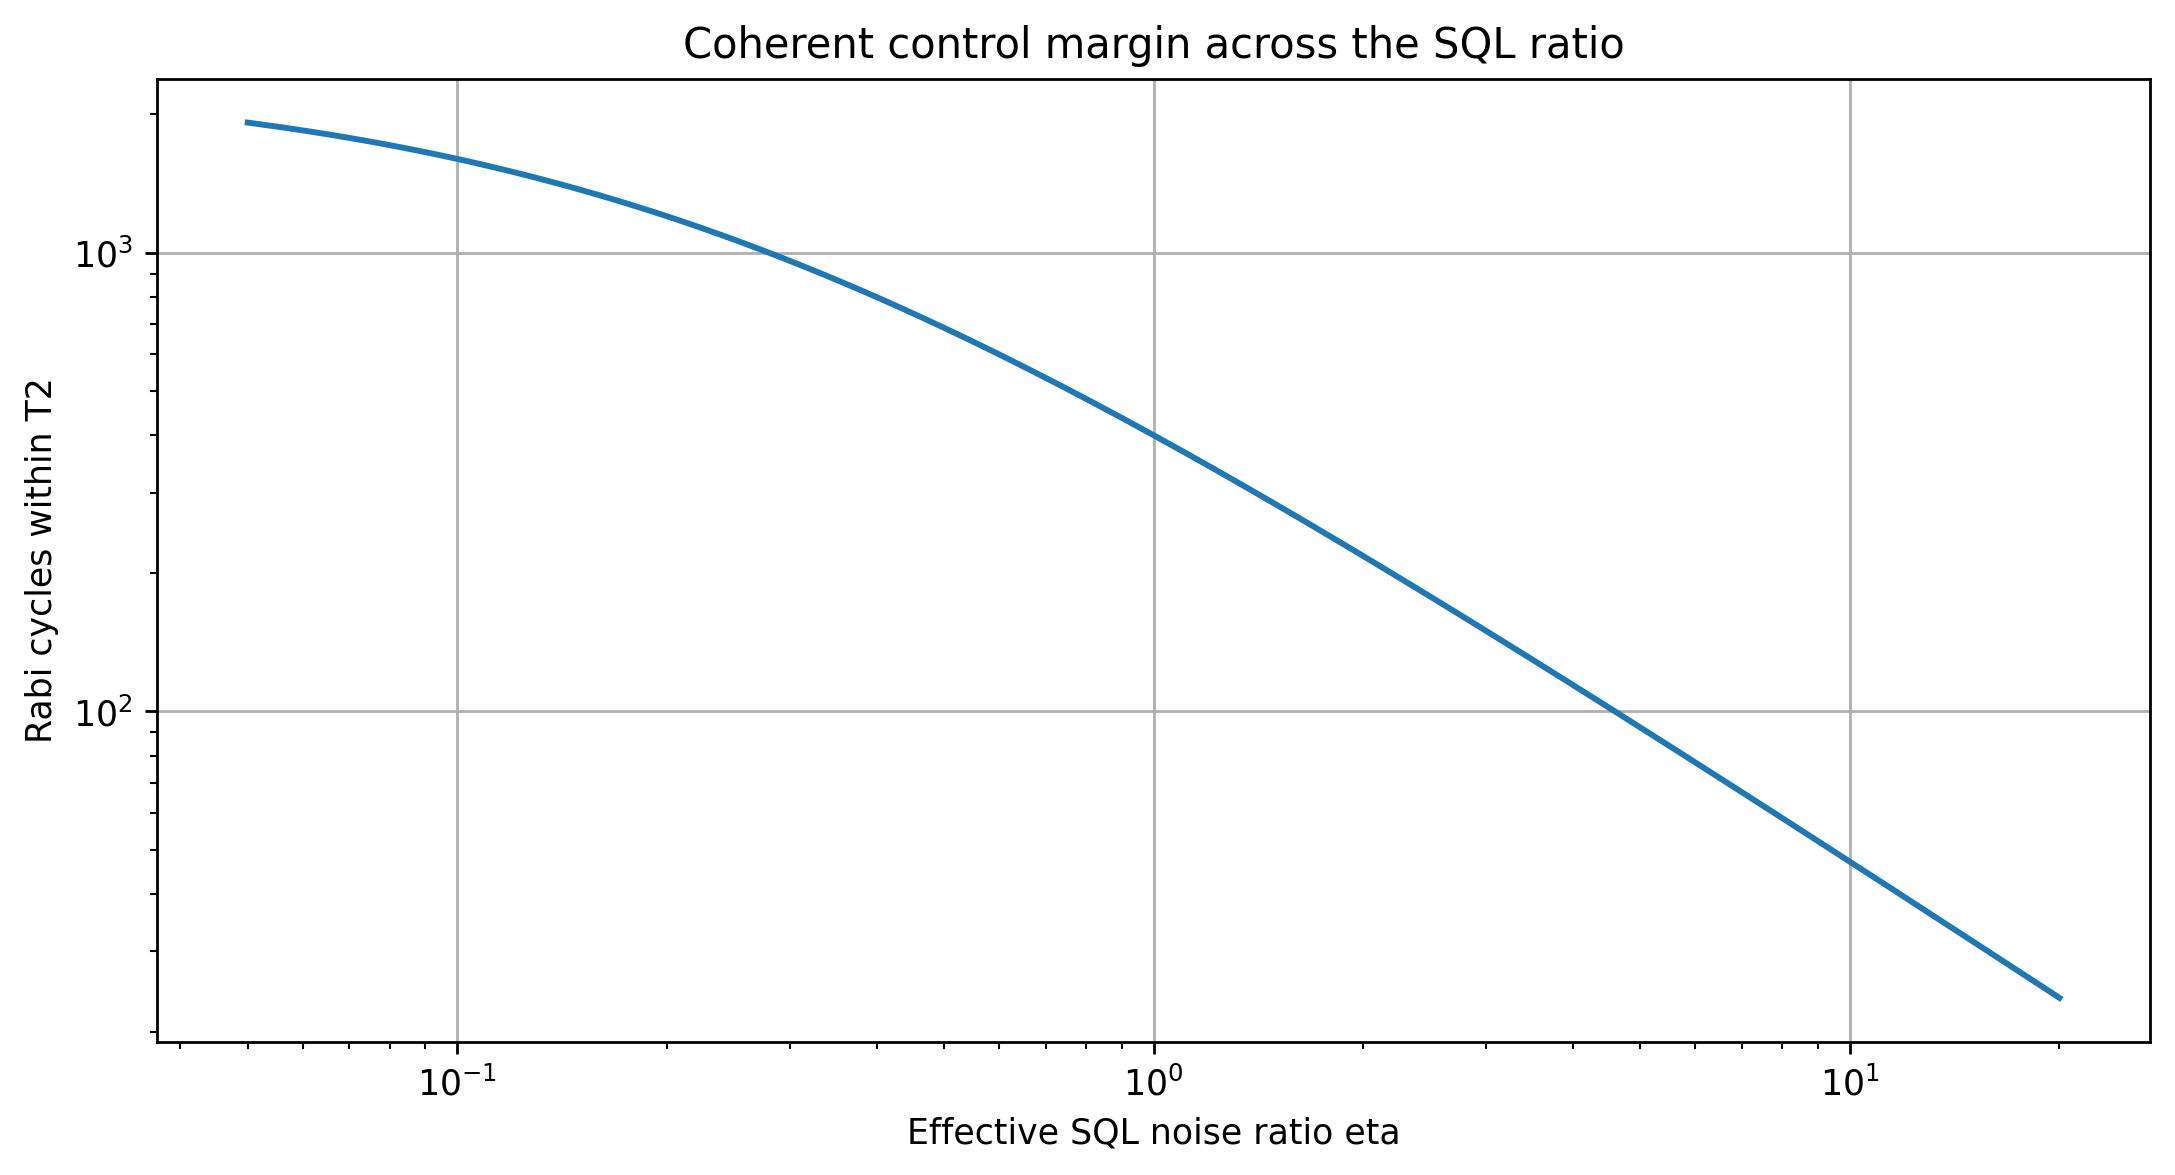

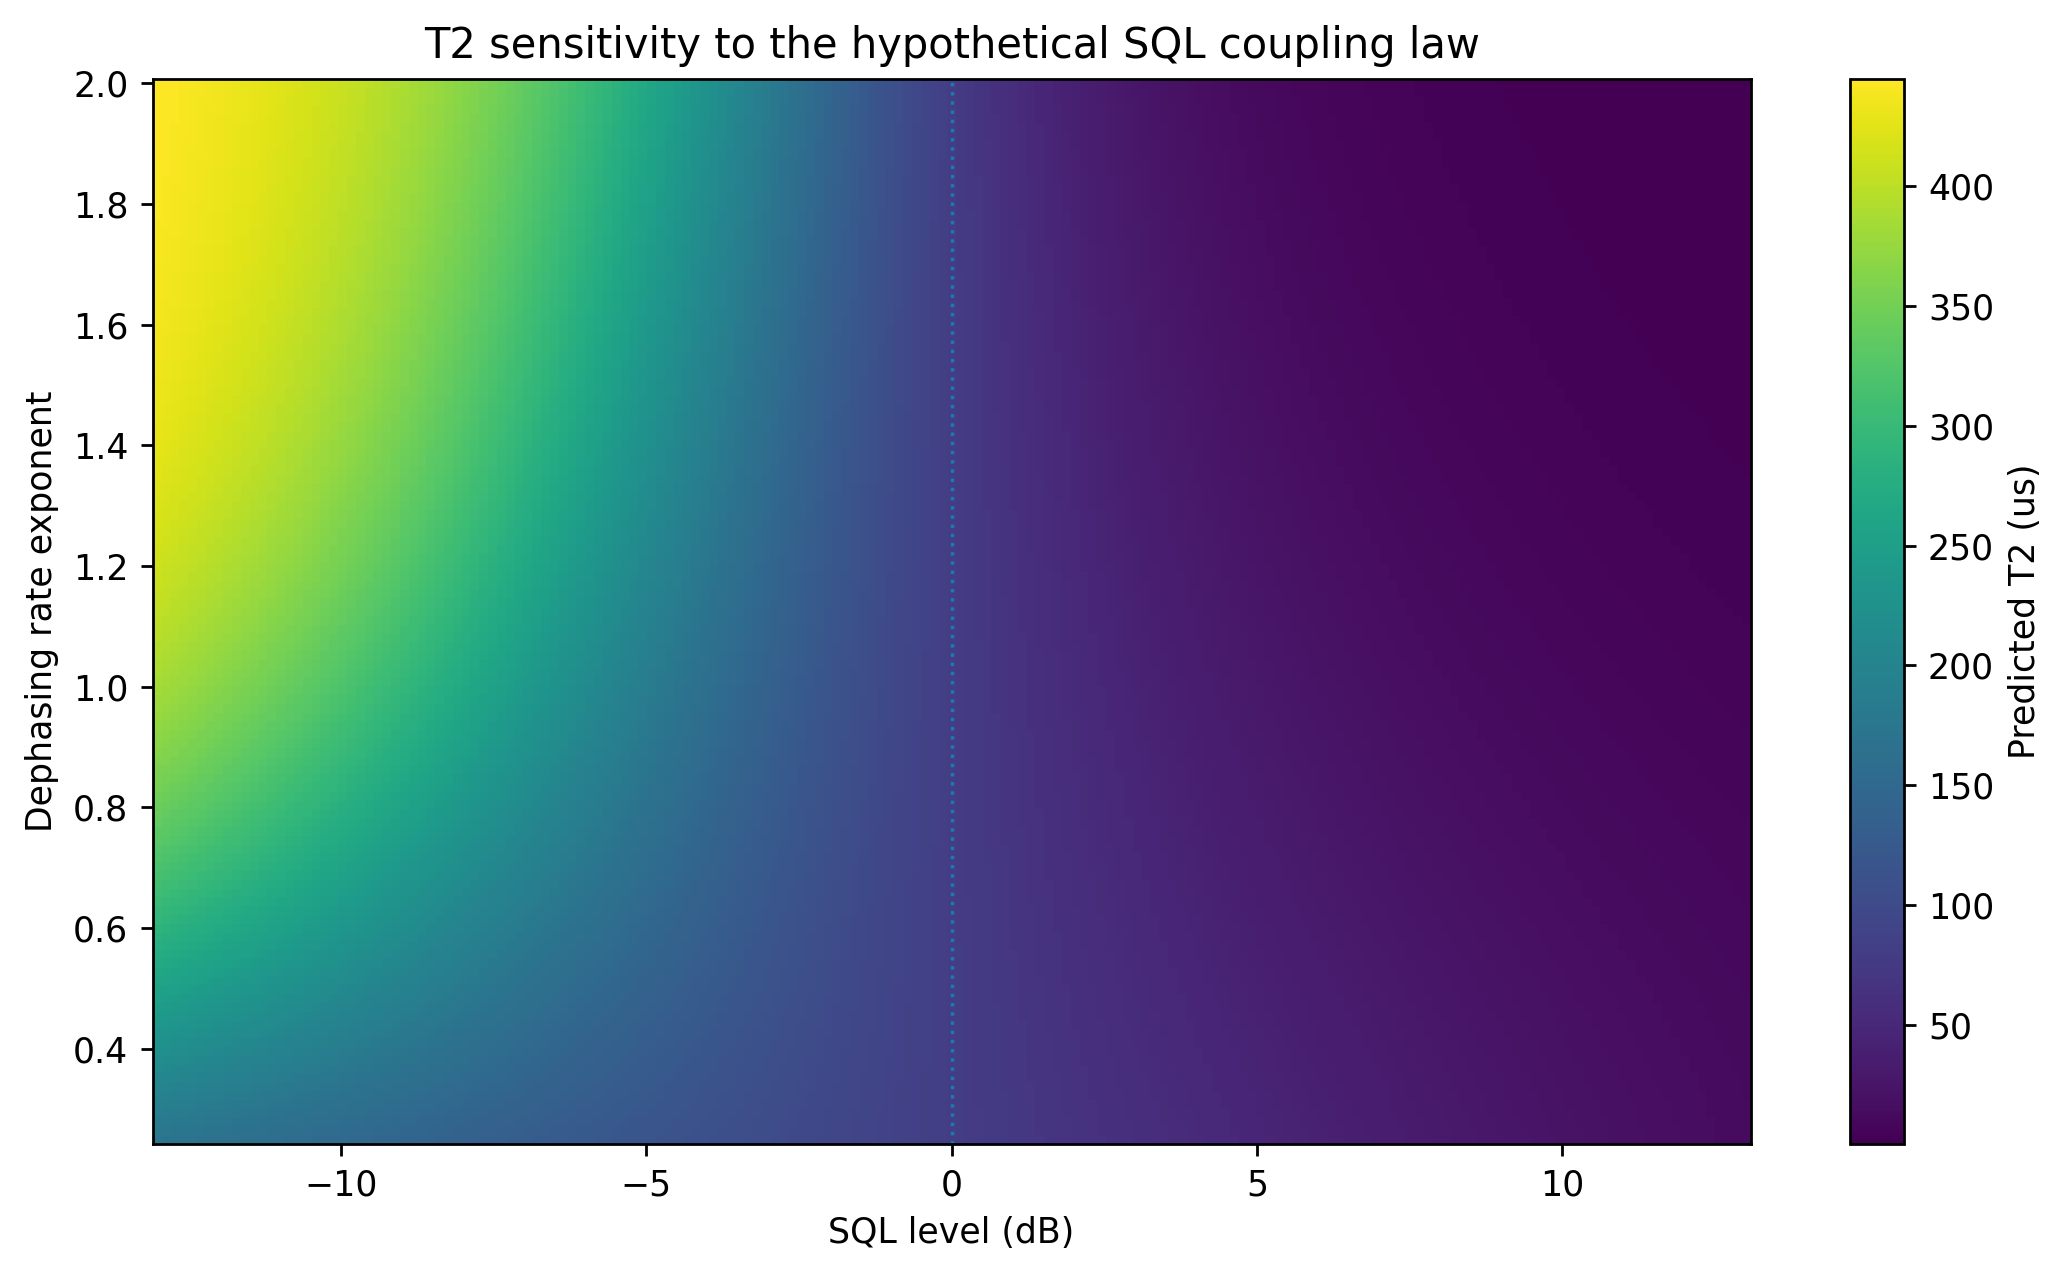

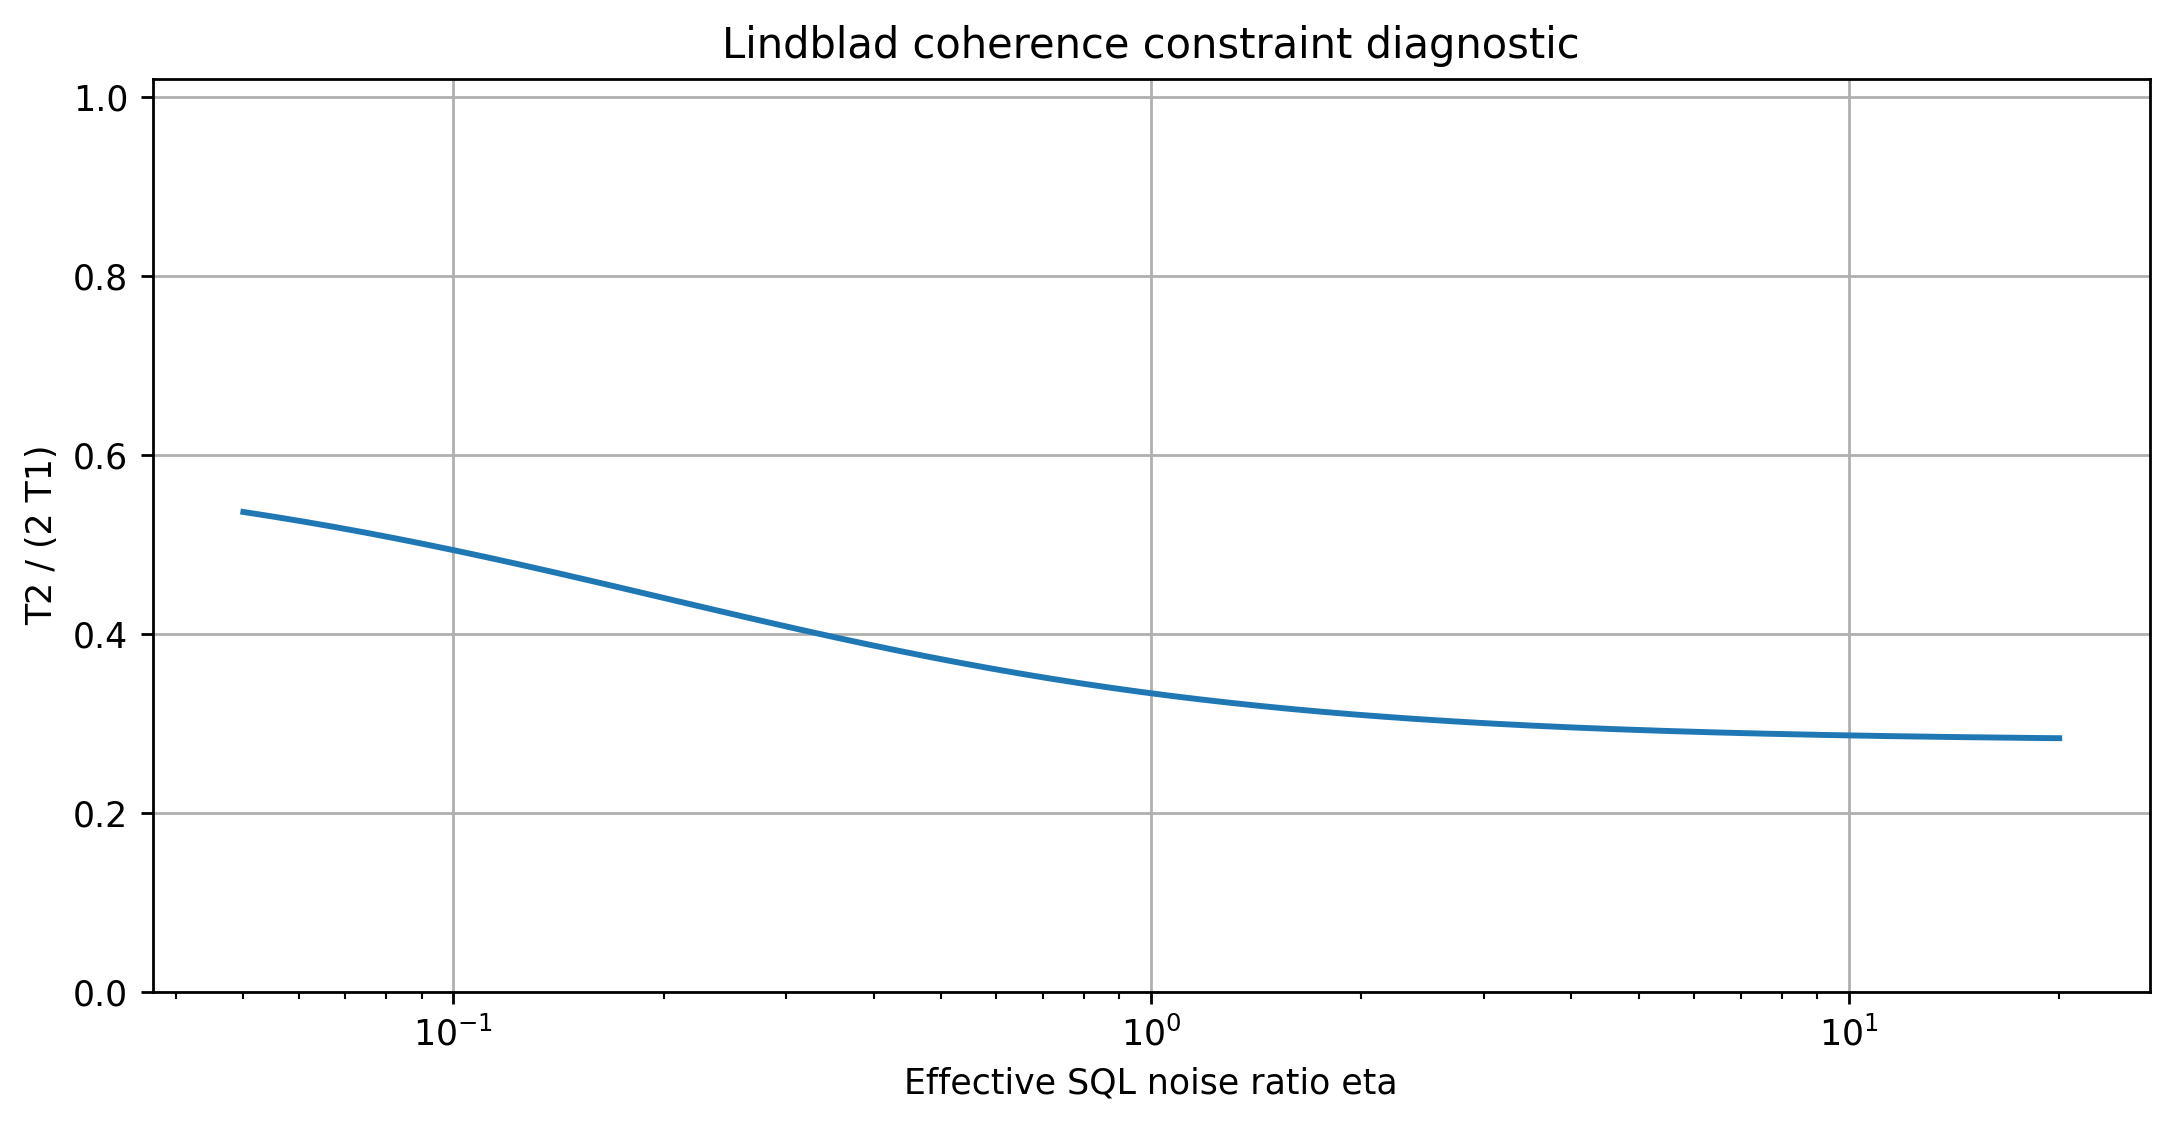

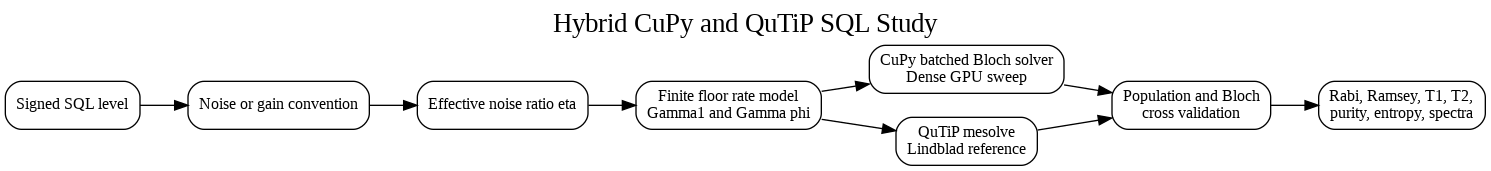

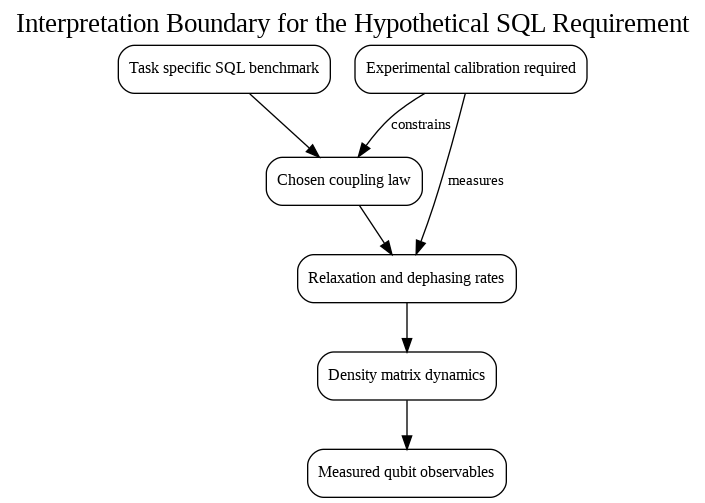


Cross validation summary
      Scenario  Max |QuTiP minus CuPy|  Max Bloch error  Max trace error  Minimum rho eigenvalue
 Far below SQL              0.00002909       0.00005864   2.22044605e-16                     0.0
Near below SQL              0.00002852       0.00005748   2.22044605e-16                     0.0
        At SQL              0.00002784       0.00005609   2.22044605e-16                     0.0
Near above SQL              0.00002653       0.00005344   2.22044605e-16                     0.0
 Far above SQL              0.00001801       0.00003618   2.22044605e-16                     0.0


In [2]:
# @title Cell 2: Run the hybrid study, validate the solvers, and render all results

# =============================================================================
# Parameter grids and simulations
# =============================================================================
scenario_labels = list(SCENARIO_DB.keys())
scenario_db = np.asarray(
    [SCENARIO_DB[label] for label in scenario_labels],
    dtype=float,
)
scenario_eta = np.asarray(db_to_noise_ratio(scenario_db), dtype=float)

time_us = np.linspace(0.0, TIME_MAX_US, N_TIME)
eta_continuous = np.logspace(
    np.log10(ETA_MIN),
    np.log10(ETA_MAX),
    N_ETA,
)
eta_db_continuous = np.asarray(
    noise_ratio_to_db(eta_continuous),
    dtype=float,
)

print("Running the five scenario CuPy simulation.")
cupy_scenarios = simulate_bloch_cupy(scenario_eta, time_us)

print("Running the dense CuPy SQL sweep.")
cupy_sweep = simulate_bloch_cupy(eta_continuous, time_us)

print("Running the QuTiP Lindblad reference simulations.")
qutip_scenarios = simulate_qutip_reference(scenario_eta, time_us)

print(
    f"CuPy scenario time: "
    f"{float(cupy_scenarios['elapsed_seconds']):.6f} s"
)
print(
    f"CuPy dense sweep time: "
    f"{float(cupy_sweep['elapsed_seconds']):.6f} s"
)
print(
    f"QuTiP reference time: "
    f"{float(qutip_scenarios['elapsed_seconds']):.6f} s"
)

# =============================================================================
# Cross validation and derived metrics
# =============================================================================
population_residual = (
    qutip_scenarios["p_excited"]
    - cupy_scenarios["p_excited"]
)
bloch_residual = np.sqrt(
    (qutip_scenarios["x"] - cupy_scenarios["x"]) ** 2
    + (qutip_scenarios["y"] - cupy_scenarios["y"]) ** 2
    + (qutip_scenarios["z"] - cupy_scenarios["z"]) ** 2
)

maximum_population_error = np.max(
    np.abs(population_residual),
    axis=1,
)
maximum_bloch_error = np.max(bloch_residual, axis=1)

pi_pulse_time_us = 1.0 / (2.0 * OMEGA_RABI_MHZ)
pi_index = int(np.argmin(np.abs(time_us - pi_pulse_time_us)))
pi_pulse_fidelity = qutip_scenarios["p_excited"][:, pi_index]

rabi_cycles_within_t2 = (
    OMEGA_RABI_MHZ * cupy_scenarios["t2_us"]
)
homogeneous_linewidth_mhz = (
    1.0 / (math.pi * cupy_scenarios["t2_us"])
)

summary_table = pd.DataFrame(
    {
        "Scenario": scenario_labels,
        "SQL level (dB)": scenario_db,
        "Noise ratio eta": scenario_eta,
        "T1 (us)": cupy_scenarios["t1_us"],
        "Tphi (us)": cupy_scenarios["tphi_us"],
        "T2 (us)": cupy_scenarios["t2_us"],
        "T2 / (2 T1)": (
            cupy_scenarios["t2_us"]
            / (2.0 * cupy_scenarios["t1_us"])
        ),
        "Pi pulse fidelity": pi_pulse_fidelity,
        "Rabi cycles in T2": rabi_cycles_within_t2,
        "Linewidth (MHz)": homogeneous_linewidth_mhz,
        "Minimum purity": np.min(
            qutip_scenarios["purity"],
            axis=1,
        ),
        "Maximum entropy (bits)": np.max(
            qutip_scenarios["entropy_bits"],
            axis=1,
        ),
        "Max |QuTiP minus CuPy|": maximum_population_error,
        "Max Bloch error": maximum_bloch_error,
        "Max trace error": qutip_scenarios["trace_error"],
        "Minimum rho eigenvalue": (
            qutip_scenarios["minimum_eigenvalue"]
        ),
    }
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.precision", 8)
display(summary_table)

# =============================================================================
# GPU frequency domain calculation
# =============================================================================
time_step_us = float(time_us[1] - time_us[0])
p_excited_gpu = cp.asarray(
    cupy_sweep["p_excited"],
    dtype=cp.float64,
)
p_excited_centered_gpu = (
    p_excited_gpu
    - cp.mean(p_excited_gpu, axis=1, keepdims=True)
)
spectrum_gpu = cp.abs(
    cp.fft.rfft(p_excited_centered_gpu, axis=1)
)
spectrum_gpu /= (
    cp.max(spectrum_gpu, axis=1, keepdims=True)
    + cp.finfo(cp.float64).eps
)
frequency_mhz_gpu = cp.fft.rfftfreq(
    N_TIME,
    d=time_step_us,
)

frequency_mhz = cp.asnumpy(frequency_mhz_gpu)
spectrum = cp.asnumpy(spectrum_gpu)
frequency_mask = frequency_mhz <= FFT_MAX_MHZ

# =============================================================================
# GPU Ramsey fringe calculation
# =============================================================================
time_gpu = cp.asarray(time_us, dtype=cp.float64)[None, :]
t2_sweep_gpu = cp.asarray(
    cupy_sweep["t2_us"],
    dtype=cp.float64,
)[:, None]
ramsey_probability_gpu = 0.5 * (
    1.0
    + cp.exp(-time_gpu / t2_sweep_gpu)
    * cp.cos(
        2.0
        * math.pi
        * RAMSEY_DETUNING_MHZ
        * time_gpu
    )
)
ramsey_probability = cp.asnumpy(ramsey_probability_gpu)

# =============================================================================
# GPU model sensitivity calculation
# =============================================================================
sensitivity_alpha = np.linspace(
    SENSITIVITY_ALPHA_MIN,
    SENSITIVITY_ALPHA_MAX,
    N_SENSITIVITY_ALPHA,
)
eta_sensitivity_gpu = cp.asarray(
    eta_continuous,
    dtype=cp.float64,
)[None, :]
alpha_sensitivity_gpu = cp.asarray(
    sensitivity_alpha,
    dtype=cp.float64,
)[:, None]

gamma_1_sensitivity_gpu, _, _, _, _ = sql_rate_model(
    eta_sensitivity_gpu,
    cp,
)
gamma_phi_factor_sensitivity_gpu = (
    1.0
    - TPHI_SQL_COUPLED_FRACTION
    + TPHI_SQL_COUPLED_FRACTION
    * cp.power(
        eta_sensitivity_gpu,
        alpha_sensitivity_gpu,
    )
)
gamma_phi_sensitivity_gpu = (
    gamma_phi_sql * gamma_phi_factor_sensitivity_gpu
)
t2_sensitivity_gpu = 1.0 / (
    0.5 * gamma_1_sensitivity_gpu
    + gamma_phi_sensitivity_gpu
)
t2_sensitivity_us = cp.asnumpy(t2_sensitivity_gpu)

# =============================================================================
# Plot 1: Rabi oscillations for the five scenarios
# =============================================================================
plt.figure(figsize=(8.8, 4.8))
for index, label in enumerate(scenario_labels):
    plt.plot(
        time_us,
        cupy_scenarios["p_excited"][index],
        linewidth=1.5,
        label=f"{label}, {scenario_db[index]:+.2f} dB",
    )
plt.xlabel("Time (us)")
plt.ylabel("Excited state probability")
plt.title("CuPy Rabi oscillations under the hypothetical SQL coupling")
plt.ylim(-0.02, 1.02)
plt.grid(True)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 2: QuTiP and CuPy population residuals
# =============================================================================
plt.figure(figsize=(8.8, 4.6))
for index, label in enumerate(scenario_labels):
    plt.plot(
        time_us,
        population_residual[index],
        linewidth=1.2,
        label=label,
    )
plt.xlabel("Time (us)")
plt.ylabel("QuTiP minus CuPy population")
plt.title("Independent solver cross validation")
plt.grid(True)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 3: Dense 2D Rabi heatmap
# =============================================================================
plt.figure(figsize=(8.8, 5.0))
heatmap = plt.pcolormesh(
    time_us,
    eta_db_continuous,
    cupy_sweep["p_excited"],
    shading="auto",
)
plt.axhline(0.0, linewidth=1.0, linestyle=":")
plt.xlabel("Time (us)")
plt.ylabel("SQL level (dB)")
plt.title("Rabi population across the SQL noise axis")
colorbar = plt.colorbar(heatmap)
colorbar.set_label("Excited state probability")
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 4: Focused 3D Rabi population surface
# =============================================================================
# A 5 MHz drive produces 30 cycles over the complete 6 us simulation. Plotting
# all cycles as one surface creates severe self-occlusion and apparent vertical
# fins. The full record remains available in Plot 3, and this view resolves the
# first selected number of drive cycles with scalar-mapped face colors.
surface_time_limit_us = min(
    TIME_MAX_US,
    SURFACE_MAX_RABI_CYCLES / OMEGA_RABI_MHZ,
)
surface_time_candidates = np.flatnonzero(
    time_us <= surface_time_limit_us
)

surface_time_indices = np.unique(
    np.linspace(
        surface_time_candidates[0],
        surface_time_candidates[-1],
        min(
            SURFACE_TIME_POINTS,
            surface_time_candidates.size,
        ),
        dtype=int,
    )
)
surface_eta_indices = np.unique(
    np.linspace(
        0,
        eta_db_continuous.size - 1,
        min(
            SURFACE_ETA_POINTS,
            eta_db_continuous.size,
        ),
        dtype=int,
    )
)

time_surface = time_us[surface_time_indices]
rabi_cycle_surface = OMEGA_RABI_MHZ * time_surface
db_surface = eta_db_continuous[surface_eta_indices]
population_surface = cupy_sweep["p_excited"][
    np.ix_(
        surface_eta_indices,
        surface_time_indices,
    )
]

cycle_mesh, db_mesh = np.meshgrid(
    rabi_cycle_surface,
    db_surface,
)

default_cmap = plt.colormaps[rcParams["image.cmap"]]
population_norm = Normalize(vmin=0.0, vmax=1.0)

figure = plt.figure(figsize=(10.0, 6.2))
axis = figure.add_subplot(111, projection="3d")
surface = axis.plot_surface(
    cycle_mesh,
    db_mesh,
    population_surface,
    cmap=default_cmap,
    norm=population_norm,
    rcount=population_surface.shape[0],
    ccount=population_surface.shape[1],
    linewidth=0.0,
    antialiased=True,
    shade=False,
)

contour_levels = np.linspace(
    0.1,
    0.9,
    SURFACE_CONTOUR_LEVELS,
)
axis.contour(
    cycle_mesh,
    db_mesh,
    population_surface,
    zdir="z",
    offset=0.0,
    levels=contour_levels,
    cmap=default_cmap,
    norm=population_norm,
    linewidths=0.45,
)

axis.set_xlabel("Driven Rabi cycles", labelpad=8)
axis.set_ylabel("SQL level (dB)", labelpad=8)
axis.set_zlabel("Excited state probability", labelpad=7)
axis.set_title(
    "Rabi population over the first "
    f"{SURFACE_MAX_RABI_CYCLES:g} drive cycles",
    pad=18,
)

axis.set_xlim(
    float(rabi_cycle_surface[0]),
    float(rabi_cycle_surface[-1]),
)
axis.set_ylim(
    float(db_surface[0]),
    float(db_surface[-1]),
)
axis.set_zlim(0.0, 1.0)
axis.view_init(
    elev=SURFACE_ELEVATION_DEG,
    azim=SURFACE_AZIMUTH_DEG,
)
axis.set_box_aspect((1.70, 1.00, 0.72))

axis.xaxis.set_major_locator(MaxNLocator(6))
axis.yaxis.set_major_locator(MaxNLocator(6))
axis.zaxis.set_major_locator(MaxNLocator(6))

figure.colorbar(
    surface,
    ax=axis,
    shrink=0.72,
    pad=0.09,
    label="Excited state probability",
)
figure.subplots_adjust(
    left=0.04,
    right=0.86,
    bottom=0.08,
    top=0.90,
)
plt.show()

# =============================================================================
# Plot 5: Continuous T1, Tphi, and T2 predictions
# =============================================================================
plt.figure(figsize=(8.8, 4.8))
plt.plot(
    eta_continuous,
    cupy_sweep["t1_us"],
    linewidth=1.7,
    label="T1",
)
plt.plot(
    eta_continuous,
    cupy_sweep["tphi_us"],
    linewidth=1.7,
    label="Tphi",
)
plt.plot(
    eta_continuous,
    cupy_sweep["t2_us"],
    linewidth=1.7,
    label="T2",
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Effective SQL noise ratio eta")
plt.ylabel("Coherence time (us)")
plt.title("Predicted coherence times across the SQL ratio")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 6: Scenario comparison for T1 and T2
# =============================================================================
scenario_positions = np.arange(len(scenario_labels), dtype=float)
bar_width = 0.36

plt.figure(figsize=(9.2, 4.9))
plt.bar(
    scenario_positions - 0.5 * bar_width,
    cupy_scenarios["t1_us"],
    width=bar_width,
    label="T1",
)
plt.bar(
    scenario_positions + 0.5 * bar_width,
    cupy_scenarios["t2_us"],
    width=bar_width,
    label="T2",
)
plt.xticks(
    scenario_positions,
    [
        f"{label}\n{db_value:+.2f} dB"
        for label, db_value in zip(
            scenario_labels,
            scenario_db,
        )
    ],
)
plt.ylabel("Time (us)")
plt.title("Discrete T1 and T2 predictions")
plt.grid(True, axis="y")
plt.legend()
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 7: Relaxation and dephasing contributions to Gamma2
# =============================================================================
gamma_1_half = 0.5 * cupy_sweep["gamma_1_per_us"]
gamma_phi = cupy_sweep["gamma_phi_per_us"]
gamma_2_total = gamma_1_half + gamma_phi

plt.figure(figsize=(8.8, 4.8))
plt.plot(
    eta_continuous,
    gamma_1_half,
    linewidth=1.7,
    label="Gamma1 / 2 contribution",
)
plt.plot(
    eta_continuous,
    gamma_phi,
    linewidth=1.7,
    label="Gamma phi contribution",
)
plt.plot(
    eta_continuous,
    gamma_2_total,
    linewidth=1.7,
    label="Total Gamma2",
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Effective SQL noise ratio eta")
plt.ylabel("Rate (1/us)")
plt.title("Composition of the transverse decoherence rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 8: QuTiP density matrix purity
# =============================================================================
plt.figure(figsize=(8.8, 4.8))
for index, label in enumerate(scenario_labels):
    plt.plot(
        time_us,
        qutip_scenarios["purity"][index],
        linewidth=1.5,
        label=label,
    )
plt.xlabel("Time (us)")
plt.ylabel("Purity Tr(rho squared)")
plt.title("QuTiP density matrix purity")
plt.ylim(0.48, 1.02)
plt.grid(True)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 9: QuTiP von Neumann entropy
# =============================================================================
plt.figure(figsize=(8.8, 4.8))
for index, label in enumerate(scenario_labels):
    plt.plot(
        time_us,
        qutip_scenarios["entropy_bits"][index],
        linewidth=1.5,
        label=label,
    )
plt.xlabel("Time (us)")
plt.ylabel("Von Neumann entropy (bits)")
plt.title("QuTiP mixed state entropy")
plt.ylim(-0.02, 1.02)
plt.grid(True)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 10: QuTiP Bloch vector trajectories
# =============================================================================
figure = plt.figure(figsize=(7.6, 6.2))
axis = figure.add_subplot(111, projection="3d")
for index, label in enumerate(scenario_labels):
    axis.plot(
        qutip_scenarios["x"][index],
        qutip_scenarios["y"][index],
        qutip_scenarios["z"][index],
        linewidth=1.4,
        label=label,
    )
axis.set_xlabel("Bloch x")
axis.set_ylabel("Bloch y")
axis.set_zlabel("Bloch z")
axis.set_title("QuTiP open system Bloch trajectories")
axis.legend(fontsize=7)
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 11: Rabi frequency spectrum heatmap
# =============================================================================
plt.figure(figsize=(8.8, 5.0))
spectral_heatmap = plt.pcolormesh(
    frequency_mhz[frequency_mask],
    eta_db_continuous,
    spectrum[:, frequency_mask],
    shading="auto",
)
plt.axhline(0.0, linewidth=1.0, linestyle=":")
plt.xlabel("Frequency (MHz)")
plt.ylabel("SQL level (dB)")
plt.title("GPU Rabi spectrum across the SQL axis")
spectral_colorbar = plt.colorbar(spectral_heatmap)
spectral_colorbar.set_label("Normalized spectral magnitude")
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 12: Ramsey fringe heatmap
# =============================================================================
plt.figure(figsize=(8.8, 5.0))
ramsey_heatmap = plt.pcolormesh(
    time_us,
    eta_db_continuous,
    ramsey_probability,
    shading="auto",
)
plt.axhline(0.0, linewidth=1.0, linestyle=":")
plt.xlabel("Free evolution time (us)")
plt.ylabel("SQL level (dB)")
plt.title(
    f"Ramsey fringes at {RAMSEY_DETUNING_MHZ:.2f} MHz detuning"
)
ramsey_colorbar = plt.colorbar(ramsey_heatmap)
ramsey_colorbar.set_label("Return probability")
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 13: Pi pulse fidelity by scenario
# =============================================================================
plt.figure(figsize=(9.2, 4.8))
plt.bar(
    scenario_positions,
    pi_pulse_fidelity,
)
plt.xticks(
    scenario_positions,
    [
        f"{label}\n{db_value:+.2f} dB"
        for label, db_value in zip(
            scenario_labels,
            scenario_db,
        )
    ],
)
plt.ylabel("Excited state probability at nominal pi time")
plt.title(
    f"Decoherence limited pi pulse response at "
    f"{pi_pulse_time_us:.4f} us"
)
plt.ylim(0.0, 1.02)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 14: Rabi control margin
# =============================================================================
rabi_cycles_sweep = (
    OMEGA_RABI_MHZ * cupy_sweep["t2_us"]
)

plt.figure(figsize=(8.8, 4.8))
plt.plot(
    eta_continuous,
    rabi_cycles_sweep,
    linewidth=1.7,
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Effective SQL noise ratio eta")
plt.ylabel("Rabi cycles within T2")
plt.title("Coherent control margin across the SQL ratio")
plt.grid(True)
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 15: Sensitivity to the assumed dephasing exponent
# =============================================================================
plt.figure(figsize=(8.8, 5.2))
sensitivity_heatmap = plt.pcolormesh(
    eta_db_continuous,
    sensitivity_alpha,
    t2_sensitivity_us,
    shading="auto",
)
plt.axvline(0.0, linewidth=1.0, linestyle=":")
plt.xlabel("SQL level (dB)")
plt.ylabel("Dephasing rate exponent")
plt.title("T2 sensitivity to the hypothetical SQL coupling law")
sensitivity_colorbar = plt.colorbar(sensitivity_heatmap)
sensitivity_colorbar.set_label("Predicted T2 (us)")
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 16: Physicality diagnostic T2 divided by 2 T1
# =============================================================================
physicality_ratio = (
    cupy_sweep["t2_us"]
    / (2.0 * cupy_sweep["t1_us"])
)

plt.figure(figsize=(8.8, 4.6))
plt.plot(
    eta_continuous,
    physicality_ratio,
    linewidth=1.7,
)
plt.xscale("log")
plt.xlabel("Effective SQL noise ratio eta")
plt.ylabel("T2 / (2 T1)")
plt.title("Lindblad coherence constraint diagnostic")
plt.ylim(0.0, 1.02)
plt.grid(True)
plt.tight_layout()
plt.show()

# =============================================================================
# Graphviz diagram 1: Hybrid numerical architecture
# =============================================================================
hybrid_workflow_dot = r"""
digraph HybridStudy {
    rankdir=LR;
    graph [
        labelloc="t",
        label="Hybrid CuPy and QuTiP SQL Study",
        fontsize=20
    ];
    node [shape=box, style="rounded", fontsize=12];
    edge [fontsize=11];

    sql [label="Signed SQL level"];
    convention [label="Noise or gain convention"];
    eta [label="Effective noise ratio eta"];
    rates [label="Finite floor rate model\nGamma1 and Gamma phi"];
    cupy [label="CuPy batched Bloch solver\nDense GPU sweep"];
    qutip [label="QuTiP mesolve\nLindblad reference"];
    validation [label="Population and Bloch\ncross validation"];
    outputs [label="Rabi, Ramsey, T1, T2,\npurity, entropy, spectra"];

    sql -> convention -> eta -> rates;
    rates -> cupy;
    rates -> qutip;
    cupy -> validation;
    qutip -> validation;
    validation -> outputs;
}
"""
display_graphviz(hybrid_workflow_dot)

# =============================================================================
# Graphviz diagram 2: Interpretation boundary
# =============================================================================
interpretation_dot = r"""
digraph Interpretation {
    rankdir=TB;
    graph [
        labelloc="t",
        label="Interpretation Boundary for the Hypothetical SQL Requirement",
        fontsize=20
    ];
    node [shape=box, style="rounded", fontsize=12];
    edge [fontsize=11];

    benchmark [label="Task specific SQL benchmark"];
    assumption [label="Chosen coupling law"];
    rates [label="Relaxation and dephasing rates"];
    state [label="Density matrix dynamics"];
    observables [label="Measured qubit observables"];
    experiment [label="Experimental calibration required"];

    benchmark -> assumption -> rates -> state -> observables;
    experiment -> assumption [label="constrains"];
    experiment -> rates [label="measures"];
}
"""
display_graphviz(interpretation_dot)

print("\nCross validation summary")
print(
    summary_table[
        [
            "Scenario",
            "Max |QuTiP minus CuPy|",
            "Max Bloch error",
            "Max trace error",
            "Minimum rho eigenvalue",
        ]
    ].to_string(index=False)
)